# Flattened-H `alpha_2` Sweep

Focused OW flattened-H analysis derived from `flattened_hamiltonian_analysis.ipynb`.

This notebook sweeps `alpha_2` at fixed `alpha_1 = 1`, `DW=True`, `nshell=1`, `Nx=20`, `Ny=40`, compares `dw_truncation=False` and `True`, and plots:
- the sorted real-space flattened-H spectrum,
- the `y_0`-averaged entanglement entropy for subsystem cuts `[0,N_x) x [y_0 \bmod N_y, y_0 + A_y \bmod N_y)`, with `A_y = 1, \ldots, N_y-2`.


In [1]:
# CPU / BLAS thread controls
# Run this before any non-stdlib imports in the notebook, especially numpy / matplotlib.
import os

CPU_CAP = 12
CPU_AFFINITY_RANGE = (100, 111)

cpu_start, cpu_stop = [int(v) for v in CPU_AFFINITY_RANGE]
if cpu_stop < cpu_start:
    raise ValueError(f"CPU_AFFINITY_RANGE must satisfy stop >= start, got {CPU_AFFINITY_RANGE}")

selected_cpus = list(range(cpu_start, cpu_stop + 1))
cpu_use = min(int(CPU_CAP), len(selected_cpus))
selected_cpus = selected_cpus[:cpu_use]

os.environ["MY_CPU_COUNT"] = str(cpu_use)
for _k in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "NUMEXPR_MAX_THREADS",
):
    os.environ[_k] = str(cpu_use)

try:
    os.sched_setaffinity(0, set(selected_cpus))
    print(f"CPU affinity set to cores {selected_cpus}")
except Exception as exc:
    print(f"CPU affinity not set: {exc}")

print(f"CPU_CAP={CPU_CAP}, cpu_use={cpu_use}, CPU_AFFINITY_RANGE={CPU_AFFINITY_RANGE}")


CPU affinity set to cores [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]
CPU_CAP=12, cpu_use=12, CPU_AFFINITY_RANGE=(100, 111)


## Setup


In [2]:
# Minimal path setup for imports from `src`
import sys
from pathlib import Path


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "fgtn" / "classA_U1FGTN.py").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}")


ROOT = find_repo_root(Path.cwd())
NOTEBOOK_ANALYSIS_DIR = ROOT / "notebooks" / "flattened_hamiltonian_analysis"
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"ROOT = {ROOT}")
print(f"NOTEBOOK_ANALYSIS_DIR = {NOTEBOOK_ANALYSIS_DIR}")


ROOT = /home/abhuiyan/class_A_fermionic_adaptive_circuit
NOTEBOOK_ANALYSIS_DIR = /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis


In [3]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

classA_U1FGTN_module = importlib.import_module("fgtn.classA_U1FGTN")
importlib.reload(classA_U1FGTN_module)
classA_U1FGTN = classA_U1FGTN_module.classA_U1FGTN

np.set_printoptions(precision=6, suppress=True)

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "CMU Sans Serif" in available_fonts:
    plt.rcParams["font.family"] = "CMU Sans Serif"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    print("CMU Sans Serif not found; using DejaVu Sans")

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 7
plt.rcParams["lines.linewidth"] = 1.4
plt.rcParams["mathtext.default"] = "regular"


## Configuration


In [4]:
ALPHA_1 = 1
ALPHA_2_VALUES = [1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 3]
NX = 20
NY = 30
NSHELL = 1
DW = True
TRIAL_ORBITAL = "X"
TRIV_REGION_LOCAL_MODE = False
DW_TRUNCATION_OPTIONS = [False, True]
ENTROPY_CLIP_EPS = 1e-12

N_LAYER = 2 * NX * NY
HALF_FILLING = N_LAYER // 2
AY_VALUES = list(range(1, NY//2 + 1))

print(f"N_LAYER = {N_LAYER}")
print(f"HALF_FILLING = {HALF_FILLING}")
print(f"alpha_2 sweep = {ALPHA_2_VALUES}")
print(f"Ay values = {AY_VALUES}")


N_LAYER = 1200
HALF_FILLING = 600
alpha_2 sweep = [1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 3]
Ay values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## Helpers


In [5]:
def contiguous_y_block(ny, length, start=0):
    start = int(start) % ny
    length = int(length)
    if length < 1 or length > ny:
        raise ValueError(f"length must lie in [1, {ny}], got {length}")
    return (np.arange(length, dtype=int) + start) % ny


def subsystem_indices(nx, ny, x_vals, y_vals):
    x_vals = np.asarray(x_vals, dtype=int)
    y_vals = np.asarray(y_vals, dtype=int)
    idx = []
    for y in y_vals:
        base_y = 2 * nx * int(y)
        for x in x_vals:
            x = int(x) % nx
            idx.append(base_y + 2 * x)
            idx.append(base_y + 2 * x + 1)
    return np.asarray(idx, dtype=int)


def reduced_covariance(G_top, idx):
    arr = np.asarray(G_top, dtype=np.complex128)
    return arr[np.ix_(idx, idx)]


def unflatten_to_G6(Gfull, Nx, Ny):
    nlayer = 2 * Nx * Ny
    Gfull = np.asarray(Gfull, dtype=np.complex128)
    if Gfull.shape != (nlayer, nlayer):
        raise ValueError(f"Expected ({nlayer}, {nlayer}), got {Gfull.shape}")
    G6m = Gfull.reshape((2, Nx, Ny, 2, Nx, Ny), order="F")
    return np.transpose(G6m, (1, 2, 0, 4, 5, 3))


def build_flattened_state(model, trial_orbital="X", dw_truncation=False):
    nlayer = 2 * model.Nx * model.Ny
    model.construct_OW_projectors(
        nshell=model.nshell,
        DW=model.DW,
        trial_orbitals=trial_orbital,
        dw_truncation=dw_truncation,
    )

    WA_p = model.WF_Ap.reshape(nlayer, -1)
    WB_p = model.WF_Bp.reshape(nlayer, -1)
    WA_m = model.WF_Am.reshape(nlayer, -1)
    WB_m = model.WF_Bm.reshape(nlayer, -1)

    P_Ap = WA_p @ WA_p.conj().T
    P_Bp = WB_p @ WB_p.conj().T
    P_Am = WA_m @ WA_m.conj().T
    P_Bm = WB_m @ WB_m.conj().T

    H_flat = P_Ap + P_Bp - P_Am - P_Bm
    H_flat = 0.5 * (H_flat + H_flat.conj().T)

    evals, evecs = np.linalg.eigh(H_flat)
    occ_mask = evals < 0.0
    neg_count = int(np.count_nonzero(occ_mask))
    fallback_used = False
    if neg_count != nlayer // 2:
        occ_mask = np.zeros_like(evals, dtype=bool)
        occ_mask[np.argsort(evals)[: nlayer // 2]] = True
        fallback_used = True
    occ_count = int(np.count_nonzero(occ_mask))

    U_occ = evecs[:, occ_mask]
    P_occ = U_occ @ U_occ.conj().T
    C_ow = 2.0 * P_occ.conj() - np.eye(nlayer, dtype=np.complex128)

    return {
        "H_flat": H_flat,
        "evals": np.real_if_close(evals),
        "C_ow": C_ow,
        "neg_count": neg_count,
        "occ_count": occ_count,
        "fallback_used": fallback_used,
        "spectral_gap": float(np.min(np.abs(evals))),
        "mean_abs_eval": float(np.mean(np.abs(evals))),
    }


def subsystem_entropy_from_covariance(G_sub, clip_eps=1e-12):
    G_sub = np.asarray(G_sub, dtype=np.complex128)
    rho_sub = 0.5 * (np.eye(G_sub.shape[0], dtype=np.complex128) + G_sub)
    rho_sub = 0.5 * (rho_sub + rho_sub.conj().T)
    lambdas = np.linalg.eigvalsh(rho_sub)
    lambdas = np.clip(np.real_if_close(lambdas), clip_eps, 1.0 - clip_eps)
    entropy = -np.sum(lambdas * np.log(lambdas) + (1.0 - lambdas) * np.log(1.0 - lambdas))
    return float(np.real_if_close(entropy))


def average_entropy_vs_Ay(C_ow, nx, ny, clip_eps=1e-12):
    x_vals = np.arange(nx, dtype=int)
    avg_entropy_by_Ay = []
    entropy_records = []

    for Ay in AY_VALUES:
        y0_entropies = np.empty(ny, dtype=float)
        for y0 in range(ny):
            y_vals = contiguous_y_block(ny, Ay, start=y0)
            idx = subsystem_indices(nx, ny, x_vals, y_vals)
            G_sub = reduced_covariance(C_ow, idx)
            y0_entropies[y0] = subsystem_entropy_from_covariance(G_sub, clip_eps=clip_eps)
        avg_entropy = float(np.mean(y0_entropies))
        avg_entropy_by_Ay.append(avg_entropy)
        for y0, entropy in enumerate(y0_entropies):
            entropy_records.append({
                "Ay": int(Ay),
                "y0": int(y0),
                "entropy": float(entropy),
            })

    return {
        "Ay_values": np.asarray(AY_VALUES, dtype=int),
        "avg_entropy": np.asarray(avg_entropy_by_Ay, dtype=float),
        "entropy_records": entropy_records,
    }


## Sweep Computation


In [6]:
results = {dw_truncation: {} for dw_truncation in DW_TRUNCATION_OPTIONS}
summary_rows = []

for dw_truncation in DW_TRUNCATION_OPTIONS:
    print("=" * 100)
    print(f"Running sweep for dw_truncation={dw_truncation}")
    print("=" * 100)
    for alpha_2 in ALPHA_2_VALUES:
        print(f"  alpha_2={alpha_2}")
        model = classA_U1FGTN(
            NX,
            NY,
            nshell=NSHELL,
            DW=DW,
            alpha_1=ALPHA_1,
            alpha_2=alpha_2,
        )
        state = build_flattened_state(
            model,
            trial_orbital=TRIAL_ORBITAL,
            dw_truncation=dw_truncation,
        )
        entropy_data = average_entropy_vs_Ay(
            state["C_ow"],
            nx=model.Nx,
            ny=model.Ny,
            clip_eps=ENTROPY_CLIP_EPS,
        )
        results[dw_truncation][alpha_2] = {
            "model": model,
            "state": state,
            "entropy_data": entropy_data,
        }
        summary_rows.append({
            "dw_truncation": bool(dw_truncation),
            "alpha_1": float(ALPHA_1),
            "alpha_2": float(alpha_2),
            "Nx": int(model.Nx),
            "Ny": int(model.Ny),
            "nshell": int(NSHELL),
            "nlayer": int(2 * model.Nx * model.Ny),
            "occ_count": int(state["occ_count"]),
            "neg_count": int(state["neg_count"]),
            "fallback_used": bool(state["fallback_used"]),
            "spectral_gap": float(state["spectral_gap"]),
            "mean_abs_eval": float(state["mean_abs_eval"]),
            "entropy_Ay1": float(entropy_data["avg_entropy"][0]),
            "entropy_Ay_max": float(entropy_data["avg_entropy"][-1]),
        })

summary_df = pd.DataFrame(summary_rows).sort_values(["dw_truncation", "alpha_2"]).reset_index(drop=True)
summary_df


Running sweep for dw_truncation=False
  alpha_2=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------


  alpha_2=1.2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=1.4
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=1.6
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=1.8
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=2.2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=3
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
Running sweep for dw_truncation=True
  alpha_2=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
  alpha_2=1.2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized --------------

,dw_truncation,alpha_1,alpha_2,Nx,Ny,nshell,nlayer,occ_count,neg_count,fallback_used,spectral_gap,mean_abs_eval,entropy_Ay1,entropy_Ay_max
0,False,1.0,1.0,20,30,1,1200,600,600,False,1.802517e+00,1.996518,14.211199,14.511854
1,False,1.0,1.2,20,30,1,1200,600,600,False,1.486303e+00,1.994452,13.868087,14.169512
2,False,1.0,1.4,20,30,1,1200,600,600,False,1.090262e+00,1.990439,13.457493,13.813585
3,False,1.0,1.6,20,30,1,1200,600,600,False,6.569647e-01,1.985465,12.928422,13.436170
4,False,1.0,1.8,20,30,1,1200,600,600,False,2.456843e-01,1.981761,12.201527,13.046918
5,False,1.0,2.0,20,30,1,1200,600,600,False,3.023600e-02,1.982132,11.330278,12.519792
6,False,1.0,2.2,20,30,1,1200,600,600,False,2.806805e-03,1.983546,10.706976,11.899924
7,False,1.0,3.0,20,30,1,1200,600,600,False,1.313346e-05,1.983092,9.589742,10.661788
8,True,1.0,1.0,20,30,1,1200,600,600,False,7.511085e-10,1.977113,14.870538,16.677822
9,True,1.0,1.2,20,30,1,1200,600,600,False,7.511071e-10,1.975866,14.437103,16.248734


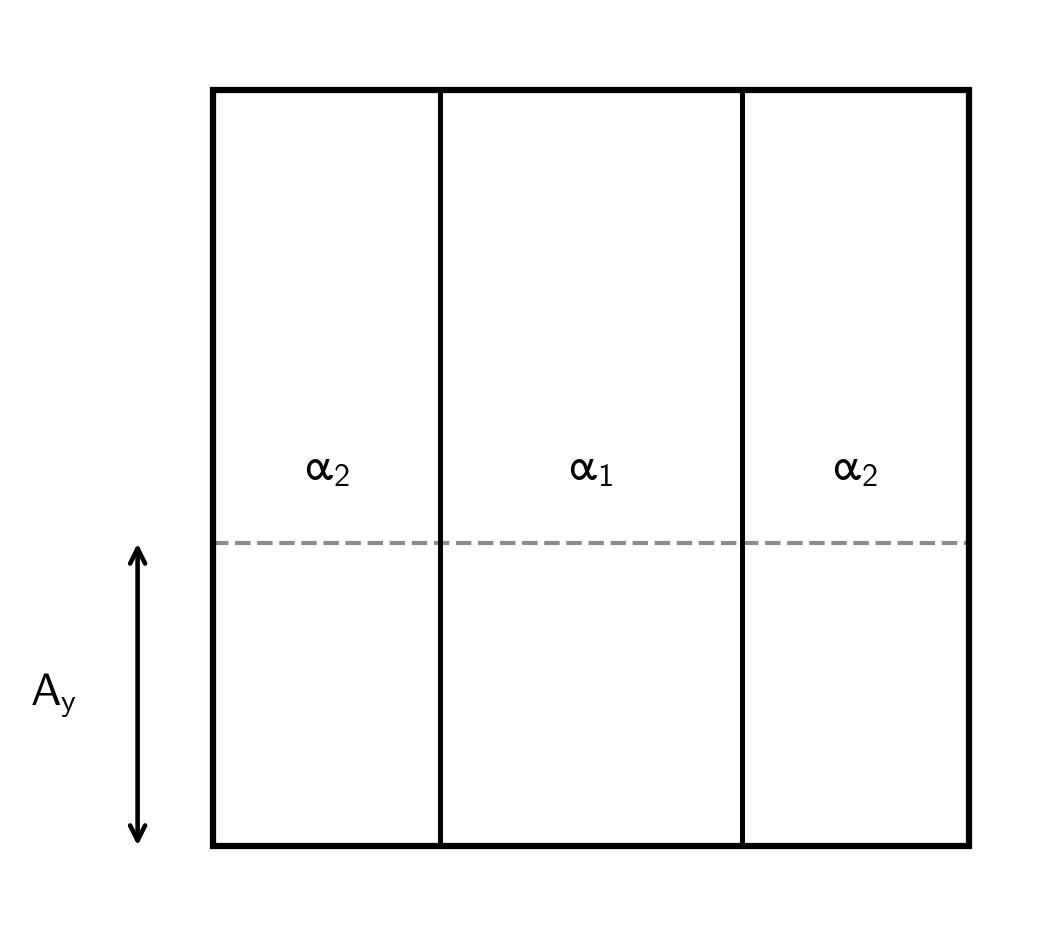

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "CMU Sans Serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
})

# -----------------------------
# Geometry
# -----------------------------
Lx = 2.0          # horizontal length
Ly = 2.0        # vertical length
x0 = 0.0          # left wall position
y0 = 0.0          # bottom line position

xc = x0 + Lx / 2
yc = y0 + Ly / 2

x_left_cut = xc - 0.2 * Lx
x_right_cut = xc + 0.2 * Lx

y_hline = y0 + 0.4 * Ly

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(3.375, 3.375), dpi=300)

# Outer rectangle
rect = patches.Rectangle(
    (x0, y0),
    Lx,
    Ly,
    fill=False,
    linewidth=1.5,
    edgecolor="black",
)
ax.add_patch(rect)

# Vertical internal lines
ax.plot([x_left_cut, x_left_cut], [y0, y0 + Ly], color="black", linewidth=1.2)
ax.plot([x_right_cut, x_right_cut], [y0, y0 + Ly], color="black", linewidth=1.2)

# Dashed horizontal line
ax.plot(
    [x0, x0 + Lx],
    [y_hline, y_hline],
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.45,
)

# Region labels
ax.text(
    xc,
    yc,
    r"$\alpha_1$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x0 + x_left_cut) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x_right_cut + x0 + Lx) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

# Double-headed arrow outside the rectangle, adjacent to left wall
arrow_x = x0 - 0.10 * Lx
ax.annotate(
    "",
    xy=(arrow_x, y_hline),
    xytext=(arrow_x, y0),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=1.1,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
)

# Ay label to the left of the double-headed arrow
ax.text(
    arrow_x - 0.08 * Lx,
    0.5 * (y0 + y_hline),
    r"$A_y$",
    ha="right",
    va="center",
    fontsize=11,
)

# -----------------------------
# Formatting
# -----------------------------
pad = 0.22 * Lx
ax.set_xlim(x0 - pad, x0 + Lx + 0.08 * Lx)
ax.set_ylim(y0 - 0.08 * Ly, y0 + Ly + 0.08 * Ly)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()

## Sorted Flattened-H Spectrum


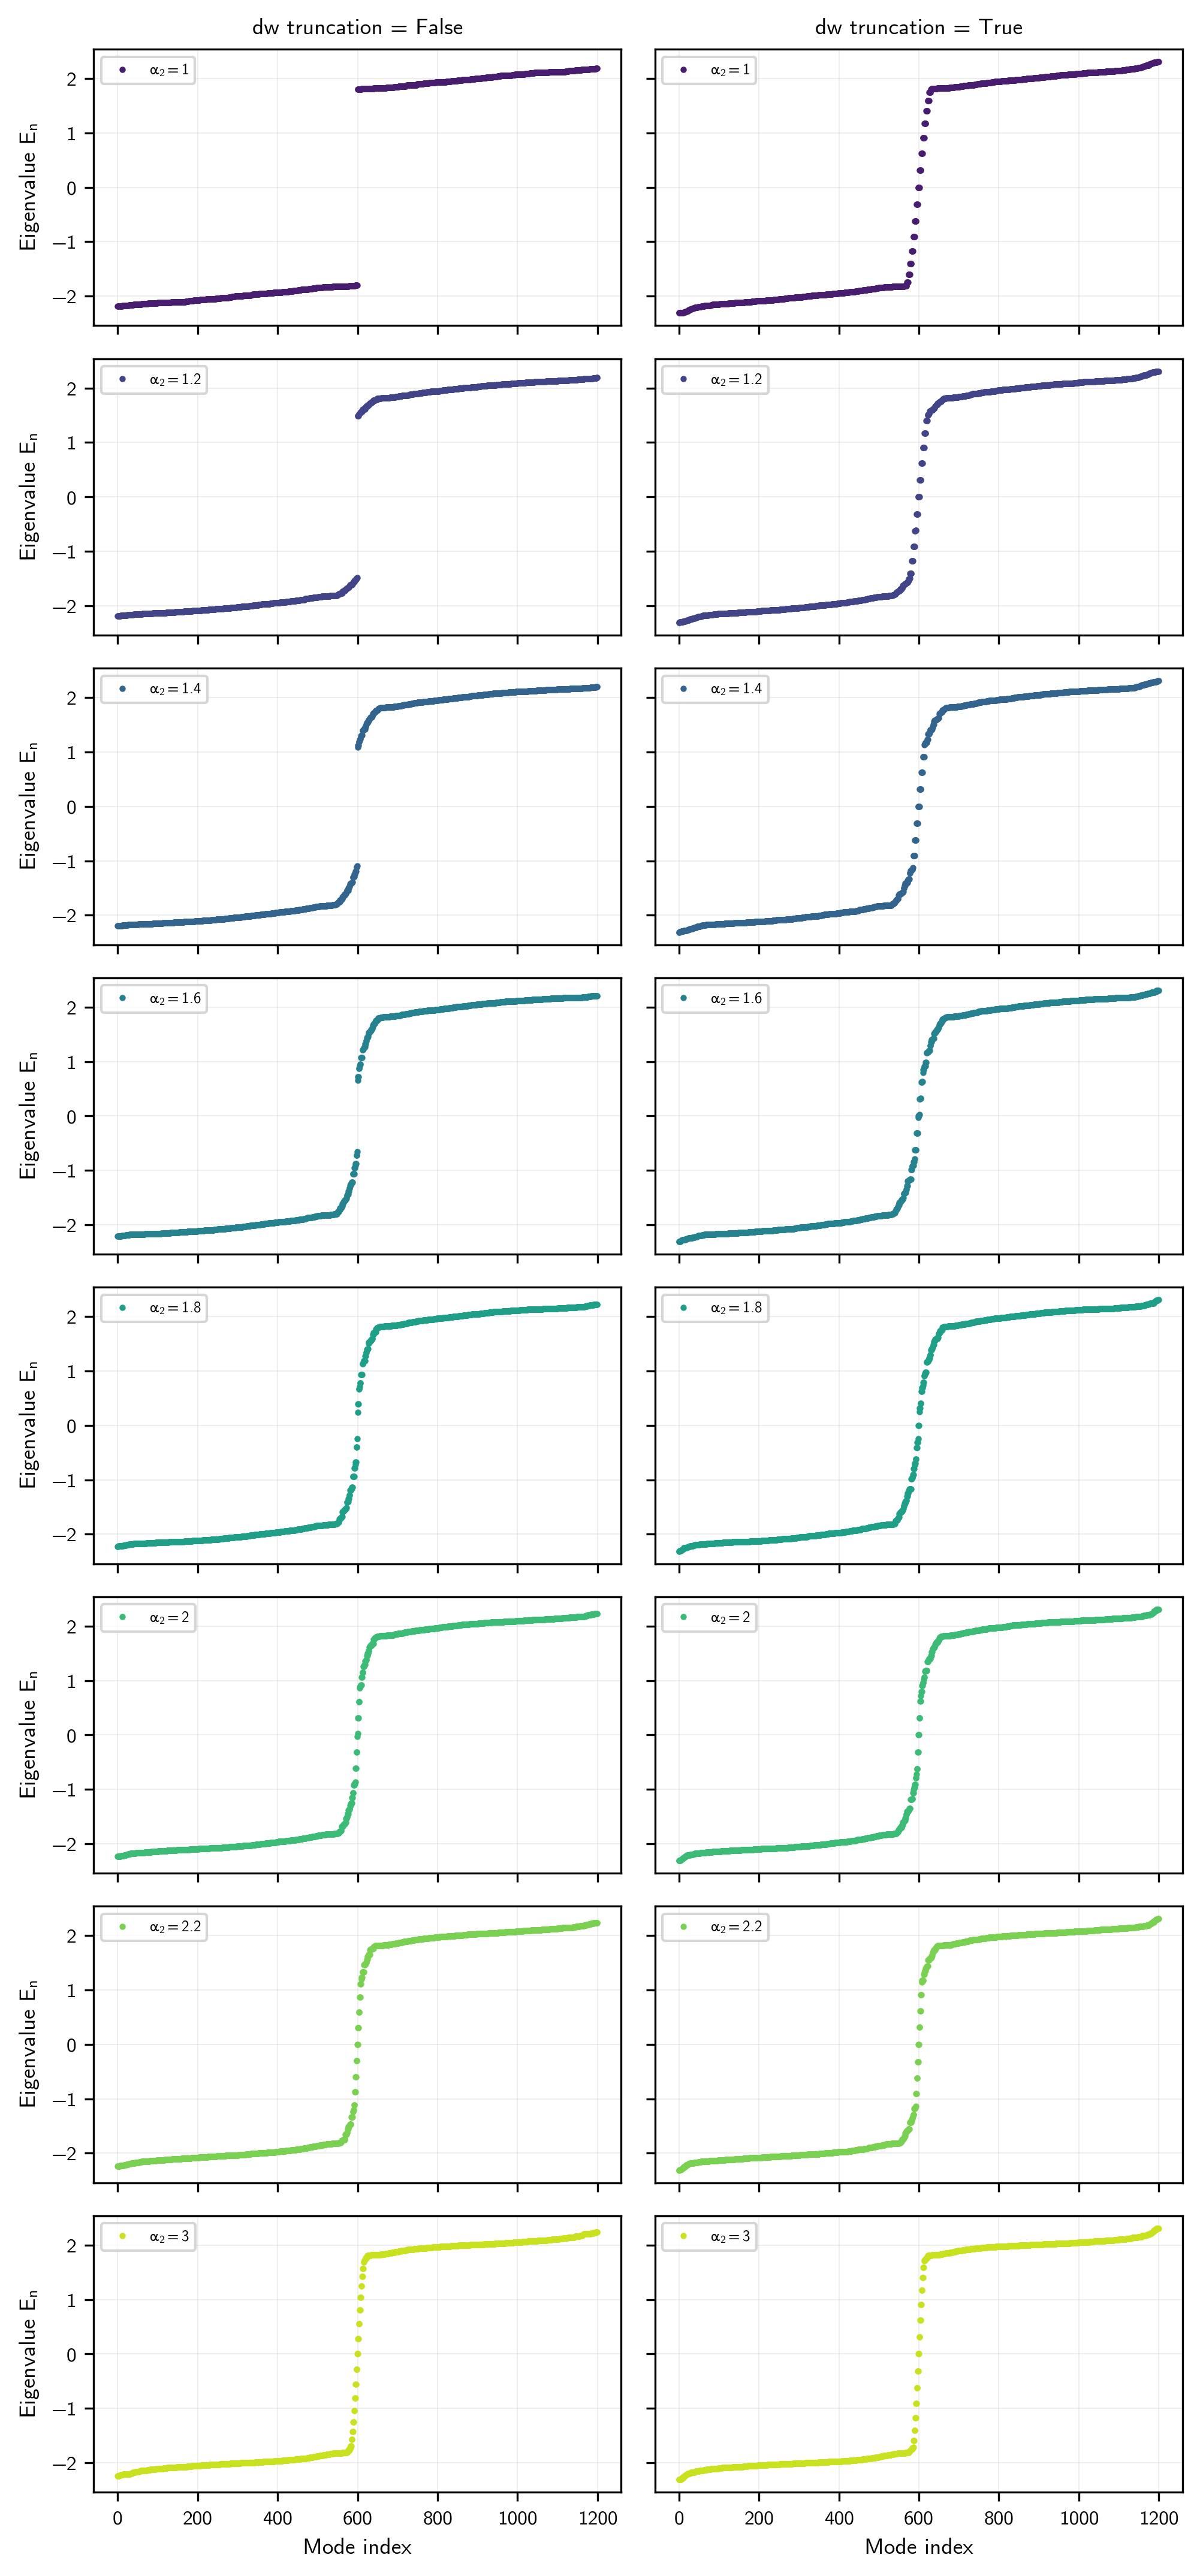

In [8]:
n_rows = len(ALPHA_2_VALUES)
n_cols = len(DW_TRUNCATION_OPTIONS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.375 * n_cols, 1.8 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

mode_index = np.arange(N_LAYER, dtype=int)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, n_rows))

for row, (alpha_2, color) in enumerate(zip(ALPHA_2_VALUES, colors)):
    for col, dw_truncation in enumerate(DW_TRUNCATION_OPTIONS):
        ax = axes[row, col]
        evals = np.sort(
            np.asarray(results[dw_truncation][alpha_2]["state"]["evals"], dtype=float)
        )
        ax.plot(
            mode_index,
            evals,
            linestyle=" ",
            marker=".",
            markersize=3,
            color=color,
            label=rf"$\alpha_2 = {alpha_2}$"
        )
        ax.grid(alpha=0.25, linewidth=0.4)
        ax.legend(loc="upper left", fontsize=6)

        if row == 0:
            ax.set_title(rf"dw truncation = {dw_truncation}")
        if col == 0:
            ax.set_ylabel(r"Eigenvalue $E_n$")
        if row == n_rows - 1:
            ax.set_xlabel("Mode index")
fig.tight_layout()
plt.show()


## `y_0`-Averaged Entanglement Entropy vs `A_y`


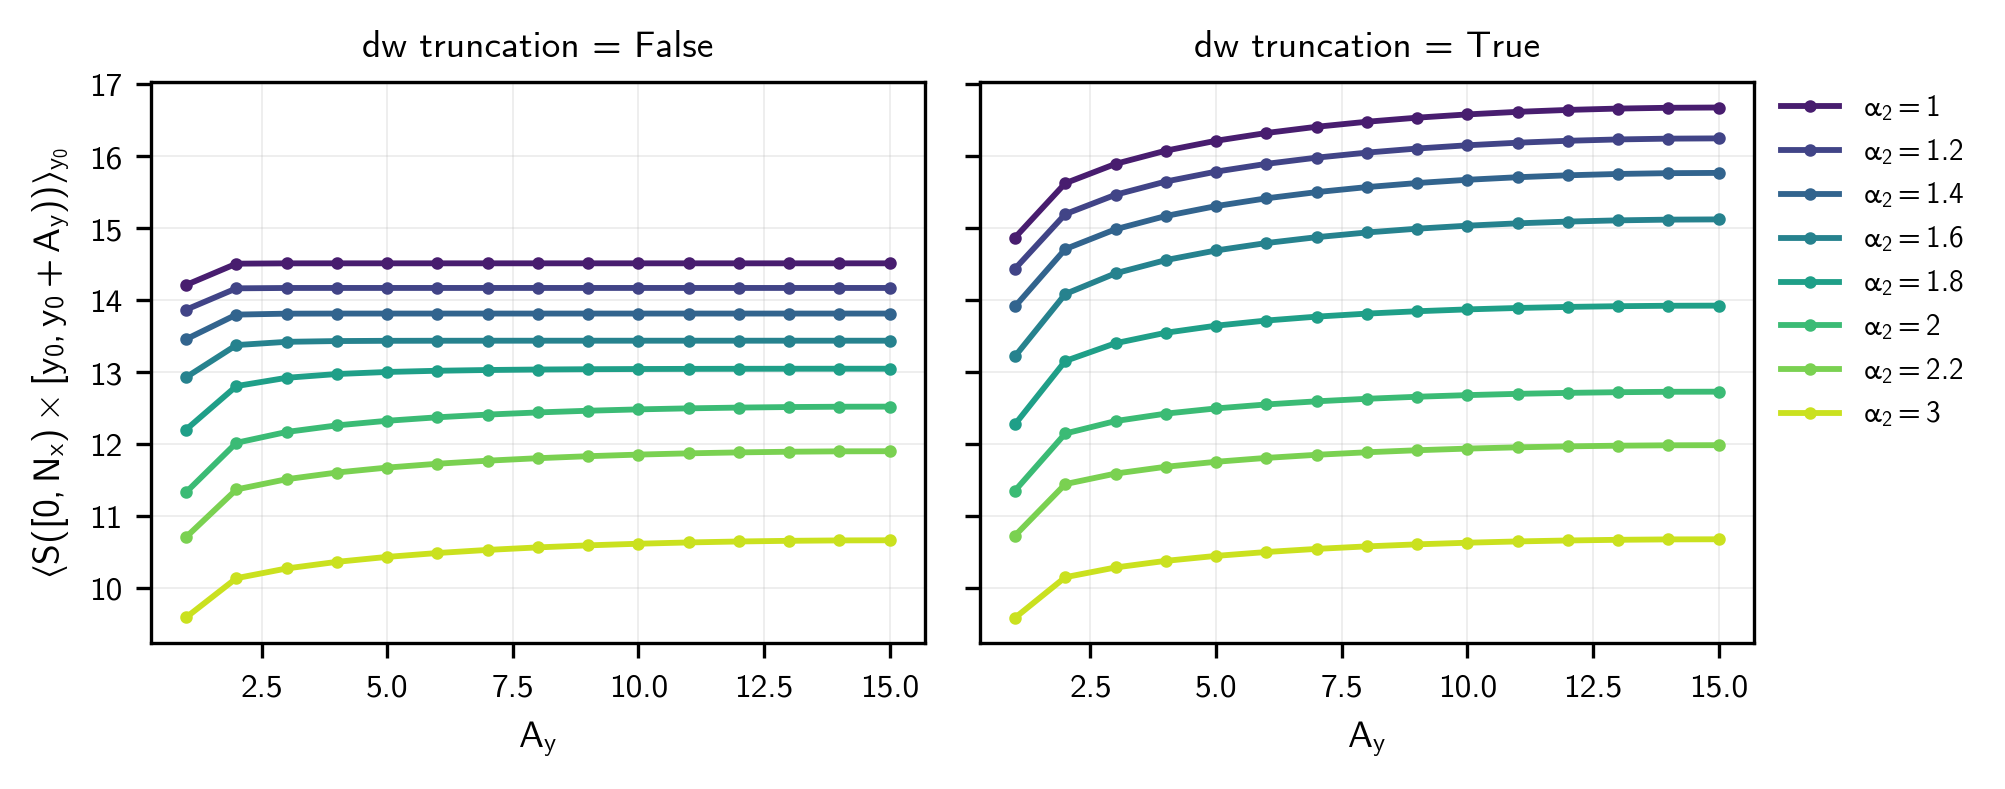

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(2 * 3.375, 2.7), sharey=True)

for ax, dw_truncation in zip(axes, DW_TRUNCATION_OPTIONS):
    for color, alpha_2 in zip(colors, ALPHA_2_VALUES):
        entropy_data = results[dw_truncation][alpha_2]["entropy_data"]
        ax.plot(
            entropy_data["Ay_values"],
            entropy_data["avg_entropy"],
            marker="o",
            markersize=2.0,
            color=color,
            label=rf"$\alpha_2={alpha_2}$",
        )
    assert len(ax.lines) == len(ALPHA_2_VALUES)
    ax.set_title(rf"dw truncation = {dw_truncation}")
    ax.set_xlabel(r"$A_y$")
    ax.grid(alpha=0.25, linewidth=0.4)

axes[0].set_ylabel(r"$\langle S([0,N_x) \times [y_0, y_0 + A_y)) \rangle_{y_0}$")
axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    ncol=1,
    borderaxespad=0,
)
fig.tight_layout()
plt.show()


## Compact Tables


In [10]:
summary_df[[
    "dw_truncation",
    "alpha_2",
    "occ_count",
    "neg_count",
    "fallback_used",
    "spectral_gap",
    "entropy_Ay1",
    "entropy_Ay_max",
]]


,dw_truncation,alpha_2,occ_count,neg_count,fallback_used,spectral_gap,entropy_Ay1,entropy_Ay_max
0,False,1.0,600,600,False,1.802517e+00,14.211199,14.511854
1,False,1.2,600,600,False,1.486303e+00,13.868087,14.169512
2,False,1.4,600,600,False,1.090262e+00,13.457493,13.813585
3,False,1.6,600,600,False,6.569647e-01,12.928422,13.436170
4,False,1.8,600,600,False,2.456843e-01,12.201527,13.046918
5,False,2.0,600,600,False,3.023600e-02,11.330278,12.519792
6,False,2.2,600,600,False,2.806805e-03,10.706976,11.899924
7,False,3.0,600,600,False,1.313346e-05,9.589742,10.661788
8,True,1.0,600,600,False,7.511085e-10,14.870538,16.677822
9,True,1.2,600,600,False,7.511071e-10,14.437103,16.248734


## Truncation-Only Central-Charge Test

This section tests whether `dw_truncation=True` can induce edge-like criticality on its own.

The falsification setup fixes `DW=True` and `dw_truncation=True`, but sets `alpha_1 = alpha_2 = alpha` so there is no physical mass domain wall. The slab geometry and truncation boundary remain, so any extracted central charge comes from the truncation-defined interface rather than a mass mismatch.

We estimate the effective central charge from the full-width strip entropy using the periodic log-chord fit

$$
S(A_y) = m \log\!\left(\frac{N_y}{\pi}\sin\frac{\pi A_y}{N_y}\right) + b,
\qquad c_{\mathrm{est}} = 3m.
$$


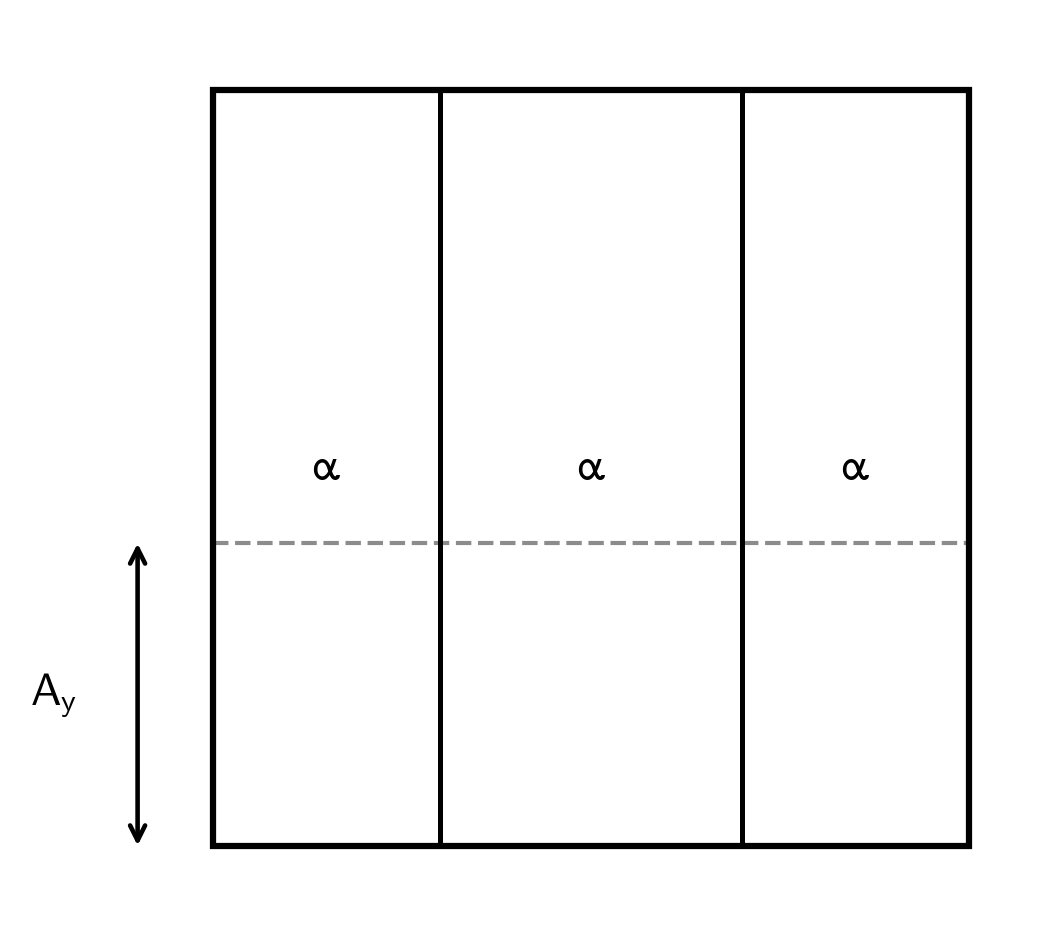

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "CMU Sans Serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
})

# -----------------------------
# Geometry
# -----------------------------
Lx = 2.0          # horizontal length
Ly = 2.0        # vertical length
x0 = 0.0          # left wall position
y0 = 0.0          # bottom line position

xc = x0 + Lx / 2
yc = y0 + Ly / 2

x_left_cut = xc - 0.2 * Lx
x_right_cut = xc + 0.2 * Lx

y_hline = y0 + 0.4 * Ly

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(3.375, 3.375), dpi=300)

# Outer rectangle
rect = patches.Rectangle(
    (x0, y0),
    Lx,
    Ly,
    fill=False,
    linewidth=1.5,
    edgecolor="black",
)
ax.add_patch(rect)

# Vertical internal lines
ax.plot([x_left_cut, x_left_cut], [y0, y0 + Ly], color="black", linewidth=1.2)
ax.plot([x_right_cut, x_right_cut], [y0, y0 + Ly], color="black", linewidth=1.2)

# Dashed horizontal line
ax.plot(
    [x0, x0 + Lx],
    [y_hline, y_hline],
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.45,
)

# Region labels
ax.text(
    xc,
    yc,
    r"$\alpha$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x0 + x_left_cut) / 2,
    yc,
    r"$\alpha$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x_right_cut + x0 + Lx) / 2,
    yc,
    r"$\alpha$",
    ha="center",
    va="center",
    fontsize=11,
)

# Double-headed arrow outside the rectangle, adjacent to left wall
arrow_x = x0 - 0.10 * Lx
ax.annotate(
    "",
    xy=(arrow_x, y_hline),
    xytext=(arrow_x, y0),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=1.1,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
)

# Ay label to the left of the double-headed arrow
ax.text(
    arrow_x - 0.08 * Lx,
    0.5 * (y0 + y_hline),
    r"$A_y$",
    ha="right",
    va="center",
    fontsize=11,
)

# -----------------------------
# Formatting
# -----------------------------
pad = 0.22 * Lx
ax.set_xlim(x0 - pad, x0 + Lx + 0.08 * Lx)
ax.set_ylim(y0 - 0.08 * Ly, y0 + Ly + 0.08 * Ly)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()

In [12]:
UNIFORM_ALPHA_VALUES = ALPHA_2_VALUES
UNIFORM_DW = True
UNIFORM_DW_TRUNCATION = True
ENTROPY_FIT_AY_MIN = 2

print(f"uniform-alpha sweep = {UNIFORM_ALPHA_VALUES}")
print(f"uniform DW = {UNIFORM_DW}, dw_truncation = {UNIFORM_DW_TRUNCATION}")
print(f"entropy fit uses Ay >= {ENTROPY_FIT_AY_MIN}")

def fit_entropy_logchord(Ay_values, entropy_values, ny, fit_ay_min=2):
    Ay_values = np.asarray(Ay_values, dtype=int)
    entropy_values = np.asarray(entropy_values, dtype=float)
    log_chord = np.log((ny / np.pi) * np.sin(np.pi * Ay_values / ny))
    fit_mask = (Ay_values >= int(fit_ay_min)) & np.isfinite(log_chord) & np.isfinite(entropy_values)
    if int(np.count_nonzero(fit_mask)) < 3:
        raise ValueError("Need at least 3 points for the entropy log-chord fit")
    x_fit = log_chord[fit_mask]
    y_fit = entropy_values[fit_mask]
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_hat = slope * x_fit + intercept
    ss_res = float(np.sum((y_fit - y_hat) ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))
    x_centered = x_fit - np.mean(x_fit)
    sxx = float(np.sum(x_centered ** 2))
    if len(x_fit) > 2 and sxx > 0.0:
        sigma2 = ss_res / float(len(x_fit) - 2)
        slope_err = float(np.sqrt(max(sigma2, 0.0) / sxx))
        intercept_err = float(np.sqrt(max(sigma2, 0.0) * (1.0 / len(x_fit) + (np.mean(x_fit) ** 2) / sxx)))
    else:
        slope_err = np.nan
        intercept_err = np.nan
    if np.isclose(ss_tot, 0.0):
        r2 = 1.0 if np.isclose(ss_res, 0.0) else 0.0
    else:
        r2 = 1.0 - ss_res / ss_tot
    return {
        "slope": float(slope),
        "slope_err": float(slope_err),
        "intercept": float(intercept),
        "intercept_err": float(intercept_err),
        "r2": float(r2),
        "log_chord": log_chord,
        "fit_mask": fit_mask,
        "fit_line": slope * log_chord + intercept,
        "c_est": float(3.0 * slope),
        "c_est_err": float(3.0 * slope_err) if np.isfinite(slope_err) else np.nan,
    }


uniform-alpha sweep = [1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 3]
uniform DW = True, dw_truncation = True
entropy fit uses Ay >= 2


In [13]:
uniform_results = {}
uniform_summary_rows = []

for alpha in UNIFORM_ALPHA_VALUES:
    print(f"uniform alpha={alpha}")
    model = classA_U1FGTN(
        NX,
        NY,
        nshell=NSHELL,
        DW=UNIFORM_DW,
        alpha_1=alpha,
        alpha_2=alpha,
    )
    state = build_flattened_state(
        model,
        trial_orbital=TRIAL_ORBITAL,
        dw_truncation=UNIFORM_DW_TRUNCATION,
    )
    entropy_data = average_entropy_vs_Ay(
        state["C_ow"],
        nx=model.Nx,
        ny=model.Ny,
        clip_eps=ENTROPY_CLIP_EPS,
    )
    fit = fit_entropy_logchord(
        entropy_data["Ay_values"],
        entropy_data["avg_entropy"],
        ny=model.Ny,
        fit_ay_min=ENTROPY_FIT_AY_MIN,
    )
    uniform_results[alpha] = {
        "model": model,
        "state": state,
        "entropy_data": entropy_data,
        "entropy_fit": fit,
    }
    uniform_summary_rows.append({
        "alpha": float(alpha),
        "slope": float(fit["slope"]),
        "slope_err": float(fit["slope_err"]),
        "c_est": float(fit["c_est"]),
        "c_est_err": float(fit["c_est_err"]),
        "intercept": float(fit["intercept"]),
        "r2": float(fit["r2"]),
        "spectral_gap": float(state["spectral_gap"]),
        "occ_count": int(state["occ_count"]),
        "neg_count": int(state["neg_count"]),
        "fallback_used": bool(state["fallback_used"]),
    })

uniform_summary_df = pd.DataFrame(uniform_summary_rows).sort_values("alpha").reset_index(drop=True)

alpha2_dw_truncation_cc_rows = []
for alpha_2 in ALPHA_2_VALUES:
    state = results[True][alpha_2]["state"]
    entropy_data = results[True][alpha_2]["entropy_data"]
    fit = fit_entropy_logchord(
        entropy_data["Ay_values"],
        entropy_data["avg_entropy"],
        ny=NY,
        fit_ay_min=ENTROPY_FIT_AY_MIN,
    )
    alpha2_dw_truncation_cc_rows.append({
        "alpha_2": float(alpha_2),
        "slope": float(fit["slope"]),
        "slope_err": float(fit["slope_err"]),
        "c_est": float(fit["c_est"]),
        "c_est_err": float(fit["c_est_err"]),
        "intercept": float(fit["intercept"]),
        "r2": float(fit["r2"]),
        "spectral_gap": float(state["spectral_gap"]),
        "occ_count": int(state["occ_count"]),
        "neg_count": int(state["neg_count"]),
        "fallback_used": bool(state["fallback_used"]),
    })

alpha2_dw_truncation_cc_df = pd.DataFrame(alpha2_dw_truncation_cc_rows).sort_values("alpha_2").reset_index(drop=True)

for alpha, record in uniform_results.items():
    state = record["state"]
    entropy_data = record["entropy_data"]
    fit = record["entropy_fit"]
    assert state["evals"].shape == (N_LAYER,)
    assert int(state["occ_count"]) == HALF_FILLING
    assert np.all(np.isfinite(entropy_data["avg_entropy"]))
    assert np.all(entropy_data["avg_entropy"] >= -1e-10)
    assert int(np.count_nonzero(fit["fit_mask"])) >= 3
    assert np.isfinite(fit["slope"])
    assert np.isfinite(fit["slope_err"])
    assert np.isfinite(fit["c_est"])
    assert np.isfinite(fit["c_est_err"])
    assert np.isfinite(fit["r2"])

comparison_df = pd.DataFrame({
    "alpha": [float(v) for v in UNIFORM_ALPHA_VALUES],
    "c_est_uniform_truncation_only": uniform_summary_df["c_est"].to_numpy(dtype=float),
    "r2_uniform_truncation_only": uniform_summary_df["r2"].to_numpy(dtype=float),
    "c_est_alpha2_sweep_dw_truncation": alpha2_dw_truncation_cc_df["c_est"].to_numpy(dtype=float),
    "r2_alpha2_sweep_dw_truncation": alpha2_dw_truncation_cc_df["r2"].to_numpy(dtype=float),
})

print("Truncation-only central-charge validation checks passed.")
uniform_summary_df


uniform alpha=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=1.2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=1.4
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=1.6
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=1.8
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=2.2
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
uniform alpha=3
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
Truncation-only central-charge validation checks passed.


,alpha,slope,slope_err,c_est,c_est_err,intercept,r2,spectral_gap,occ_count,neg_count,fallback_used
0,1.0,0.668625,0.000542,2.005874,0.001626,15.169544,0.999992,7.511085e-10,600,600,False
1,1.2,0.669024,0.000673,2.007072,0.002018,14.234036,0.999988,2.661392e-08,600,600,False
2,1.4,0.674767,0.002546,2.024302,0.007639,13.183440,0.999829,1.274791e-04,600,600,False
3,1.6,0.655113,0.010910,1.965338,0.032731,11.885700,0.996683,1.264362e-02,600,600,False
4,1.8,0.306931,0.027646,0.920793,0.082939,10.160035,0.911279,2.062316e-01,600,600,False
5,2.0,0.056871,0.011273,0.170612,0.033818,8.029446,0.679594,6.930170e-01,600,600,False
6,2.2,0.014098,0.003401,0.042293,0.010203,6.461073,0.588781,1.120418e+00,600,600,False
7,3.0,0.000777,0.000206,0.002330,0.000617,3.579540,0.543045,1.703905e+00,600,600,False


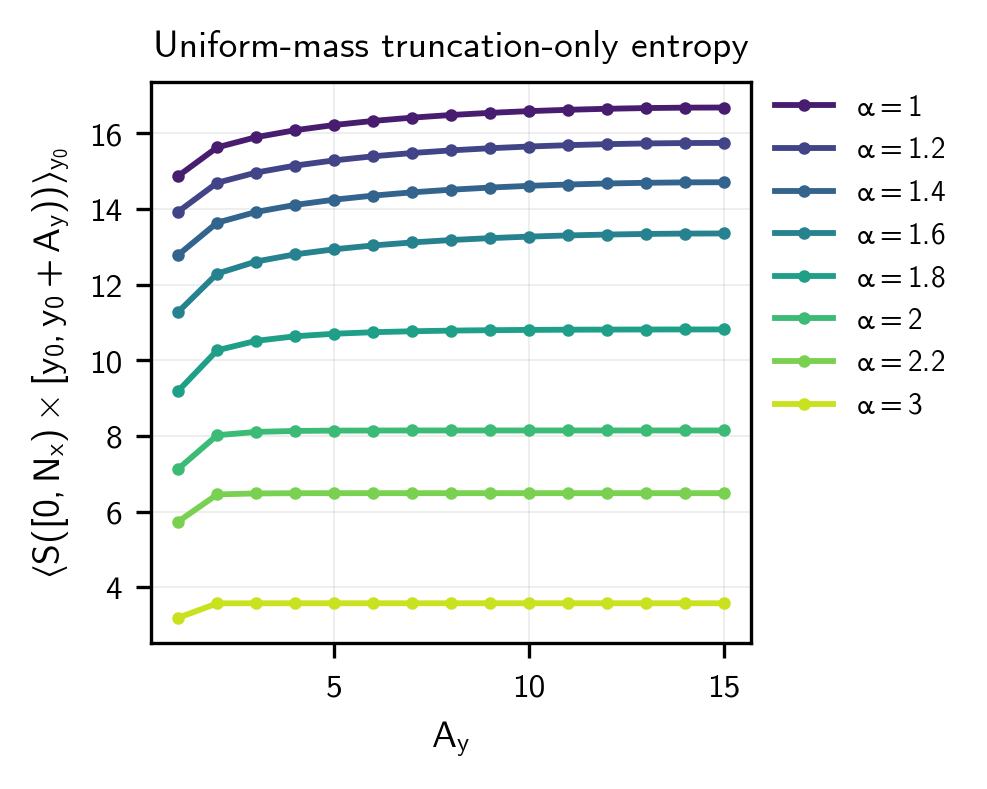

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.7))

uniform_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(UNIFORM_ALPHA_VALUES)))
for color, alpha in zip(uniform_colors, UNIFORM_ALPHA_VALUES):
    entropy_data = uniform_results[alpha]["entropy_data"]
    ax.plot(
        entropy_data["Ay_values"],
        entropy_data["avg_entropy"],
        marker="o",
        markersize=2.0,
        color=color,
        label=rf"$\alpha={alpha}$",
    )
ax.set_title(r"Uniform-mass truncation-only entropy")
ax.set_xlabel(r"$A_y$")
ax.set_ylabel(r"$\langle S([0,N_x) \times [y_0, y_0 + A_y)) \rangle_{y_0}$")
ax.grid(alpha=0.25, linewidth=0.4)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, ncol=1, borderaxespad=0)
fig.tight_layout()
plt.show()


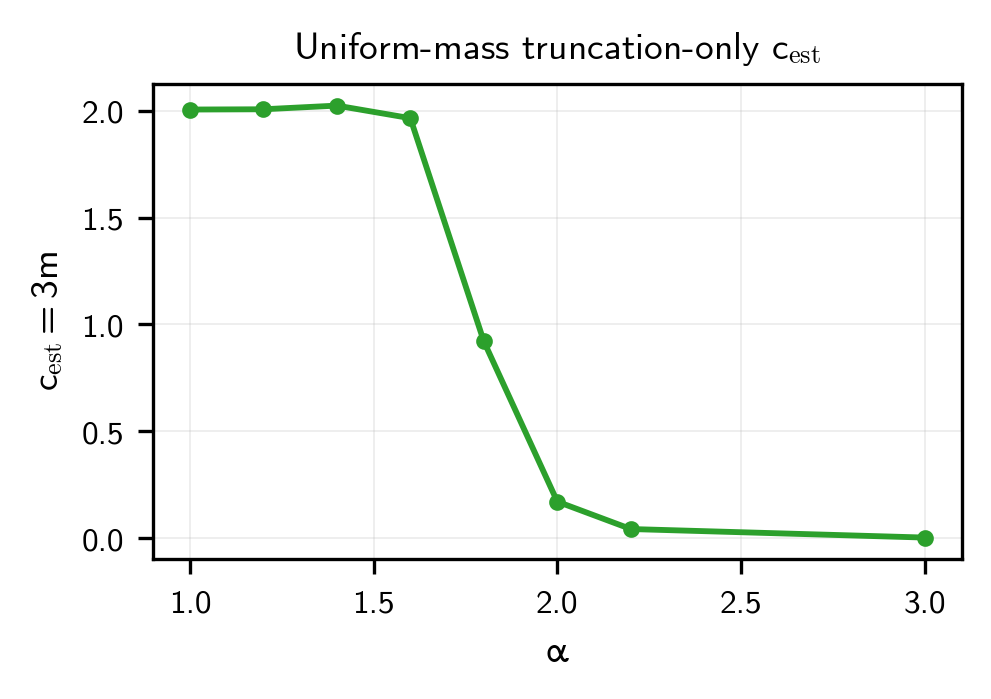

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.4))
ax.plot(
    uniform_summary_df["alpha"],
    uniform_summary_df["c_est"],
    marker="o",
    markersize=3.0,
    color="tab:green",
)
ax.set_title(r"Uniform-mass truncation-only $c_{\mathrm{est}}$")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$c_{\mathrm{est}} = 3m$")
ax.grid(alpha=0.25, linewidth=0.4)
fig.tight_layout()
plt.show()


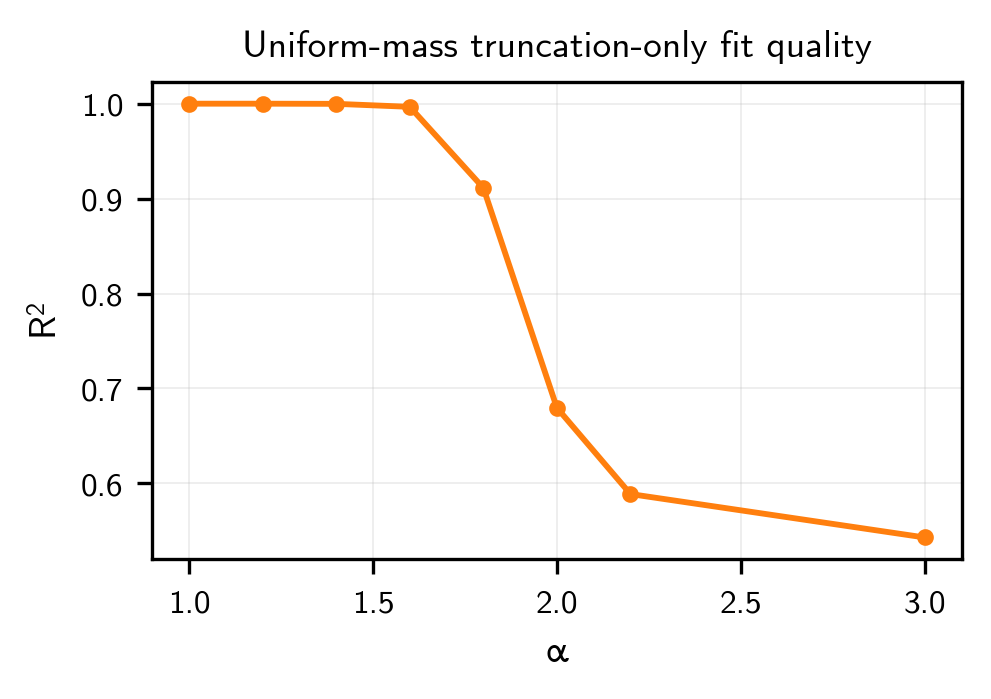

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.4))
ax.plot(
    uniform_summary_df["alpha"],
    uniform_summary_df["r2"],
    marker="o",
    markersize=3.0,
    color="tab:orange",
)
ax.set_title(r"Uniform-mass truncation-only fit quality")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$R^2$")
ax.grid(alpha=0.25, linewidth=0.4)
fig.tight_layout()
plt.show()


In [17]:
uniform_summary_df[[
    "alpha",
    "c_est",
    "slope",
    "r2",
    "spectral_gap",
    "occ_count",
    "neg_count",
    "fallback_used",
]]


,alpha,c_est,slope,r2,spectral_gap,occ_count,neg_count,fallback_used
0,1.0,2.005874,0.668625,0.999992,7.511085e-10,600,600,False
1,1.2,2.007072,0.669024,0.999988,2.661392e-08,600,600,False
2,1.4,2.024302,0.674767,0.999829,1.274791e-04,600,600,False
3,1.6,1.965338,0.655113,0.996683,1.264362e-02,600,600,False
4,1.8,0.920793,0.306931,0.911279,2.062316e-01,600,600,False
5,2.0,0.170612,0.056871,0.679594,6.930170e-01,600,600,False
6,2.2,0.042293,0.014098,0.588781,1.120418e+00,600,600,False
7,3.0,0.002330,0.000777,0.543045,1.703905e+00,600,600,False


In [18]:
comparison_df


,alpha,c_est_uniform_truncation_only,r2_uniform_truncation_only,c_est_alpha2_sweep_dw_truncation,r2_alpha2_sweep_dw_truncation
0,1.0,2.005874,0.999992,2.005874,0.999992
1,1.2,2.007072,0.999988,2.006412,0.999990
2,1.4,2.024302,0.999829,2.012633,0.999945
3,1.6,1.965338,0.996683,1.950542,0.999102
4,1.8,0.920793,0.911279,1.407365,0.990824
5,2.0,0.170612,0.679594,1.078684,0.997389
6,2.2,0.042293,0.588781,1.022036,0.999661
7,3.0,0.002330,0.543045,1.004256,0.999984


## Fixed `alpha_1 = 1` with `dw_truncation = True`

This section repeats the full-width strip-entropy characterization for the physical domain-wall sweep with `alpha_1 = 1`, `dw_truncation = True`, and a restricted set of `alpha_2` values. It uses the same log-chord fit and now reports fit-derived uncertainties for both the slope and `c_{\mathrm{est}} = 3m`.


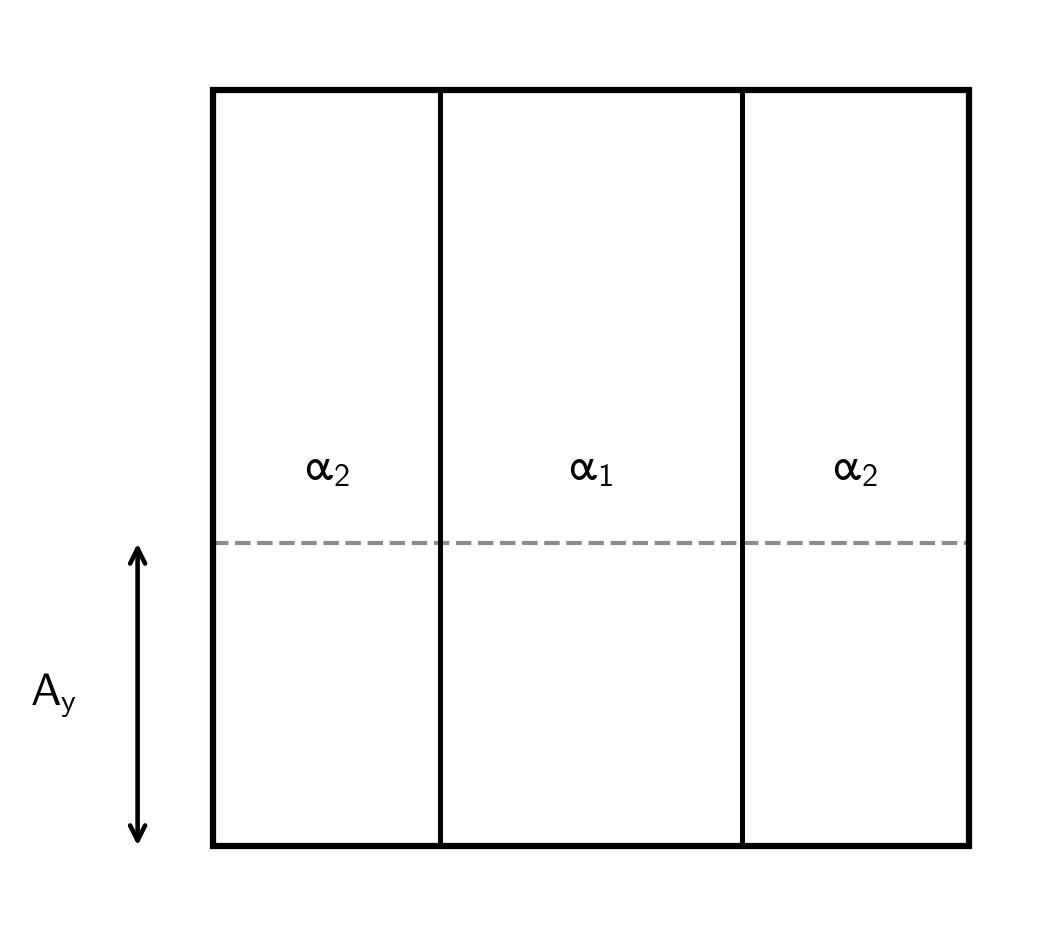

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "CMU Sans Serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
})

# -----------------------------
# Geometry
# -----------------------------
Lx = 2.0          # horizontal length
Ly = 2.0        # vertical length
x0 = 0.0          # left wall position
y0 = 0.0          # bottom line position

xc = x0 + Lx / 2
yc = y0 + Ly / 2

x_left_cut = xc - 0.2 * Lx
x_right_cut = xc + 0.2 * Lx

y_hline = y0 + 0.4 * Ly

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(3.375, 3.375), dpi=300)

# Outer rectangle
rect = patches.Rectangle(
    (x0, y0),
    Lx,
    Ly,
    fill=False,
    linewidth=1.5,
    edgecolor="black",
)
ax.add_patch(rect)

# Vertical internal lines
ax.plot([x_left_cut, x_left_cut], [y0, y0 + Ly], color="black", linewidth=1.2)
ax.plot([x_right_cut, x_right_cut], [y0, y0 + Ly], color="black", linewidth=1.2)

# Dashed horizontal line
ax.plot(
    [x0, x0 + Lx],
    [y_hline, y_hline],
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.45,
)

# Region labels
ax.text(
    xc,
    yc,
    r"$\alpha_1$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x0 + x_left_cut) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x_right_cut + x0 + Lx) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

# Double-headed arrow outside the rectangle, adjacent to left wall
arrow_x = x0 - 0.10 * Lx
ax.annotate(
    "",
    xy=(arrow_x, y_hline),
    xytext=(arrow_x, y0),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=1.1,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
)

# Ay label to the left of the double-headed arrow
ax.text(
    arrow_x - 0.08 * Lx,
    0.5 * (y0 + y_hline),
    r"$A_y$",
    ha="right",
    va="center",
    fontsize=11,
)

# -----------------------------
# Formatting
# -----------------------------
pad = 0.22 * Lx
ax.set_xlim(x0 - pad, x0 + Lx + 0.08 * Lx)
ax.set_ylim(y0 - 0.08 * Ly, y0 + Ly + 0.08 * Ly)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()

In [20]:
FIXED_ALPHA1_ALPHA2_VALUES = [1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 3]

fixed_alpha1_dwtrunc_rows = []
for alpha_2 in FIXED_ALPHA1_ALPHA2_VALUES:
    state = results[True][alpha_2]["state"]
    entropy_data = results[True][alpha_2]["entropy_data"]
    fit = fit_entropy_logchord(
        entropy_data["Ay_values"],
        entropy_data["avg_entropy"],
        ny=NY,
        fit_ay_min=ENTROPY_FIT_AY_MIN,
    )
    fixed_alpha1_dwtrunc_rows.append({
        "alpha_1": float(ALPHA_1),
        "alpha_2": float(alpha_2),
        "slope": float(fit["slope"]),
        "slope_err": float(fit["slope_err"]),
        "c_est": float(fit["c_est"]),
        "c_est_err": float(fit["c_est_err"]),
        "intercept": float(fit["intercept"]),
        "intercept_err": float(fit["intercept_err"]),
        "r2": float(fit["r2"]),
        "spectral_gap": float(state["spectral_gap"]),
        "occ_count": int(state["occ_count"]),
        "neg_count": int(state["neg_count"]),
        "fallback_used": bool(state["fallback_used"]),
    })

fixed_alpha1_dwtrunc_df = pd.DataFrame(fixed_alpha1_dwtrunc_rows).sort_values("alpha_2").reset_index(drop=True)

for alpha_2 in FIXED_ALPHA1_ALPHA2_VALUES:
    fit = fit_entropy_logchord(
        results[True][alpha_2]["entropy_data"]["Ay_values"],
        results[True][alpha_2]["entropy_data"]["avg_entropy"],
        ny=NY,
        fit_ay_min=ENTROPY_FIT_AY_MIN,
    )
    assert np.isfinite(fit["slope"])
    assert np.isfinite(fit["slope_err"])
    assert np.isfinite(fit["c_est"])
    assert np.isfinite(fit["c_est_err"])
    assert np.isfinite(fit["r2"])
    assert int(np.count_nonzero(fit["fit_mask"])) >= 3

fixed_alpha1_dwtrunc_df


,alpha_1,alpha_2,slope,slope_err,c_est,c_est_err,intercept,intercept_err,r2,spectral_gap,occ_count,neg_count,fallback_used
0,1.0,1.0,0.668625,0.000542,2.005874,0.001626,15.169544,0.001020,0.999992,7.511085e-10,600,600,False
1,1.0,1.2,0.668804,0.000600,2.006412,0.001801,14.740095,0.001129,0.999990,7.511071e-10,600,600,False
2,1.0,1.4,0.670878,0.001433,2.012633,0.004298,14.256304,0.002695,0.999945,7.511083e-10,600,600,False
3,1.0,1.6,0.650181,0.005628,1.950542,0.016885,13.662561,0.010587,0.999102,7.511082e-10,600,600,False
4,1.0,1.8,0.469122,0.013032,1.407365,0.039097,12.882927,0.024514,0.990824,7.511077e-10,600,600,False
5,1.0,2.0,0.359561,0.005310,1.078684,0.015931,11.921804,0.009989,0.997389,7.511079e-10,600,600,False
6,1.0,2.2,0.340679,0.001812,1.022036,0.005436,11.217000,0.003409,0.999661,7.511078e-10,600,600,False
7,1.0,3.0,0.334752,0.000389,1.004256,0.001168,9.920807,0.000732,0.999984,7.511082e-10,600,600,False


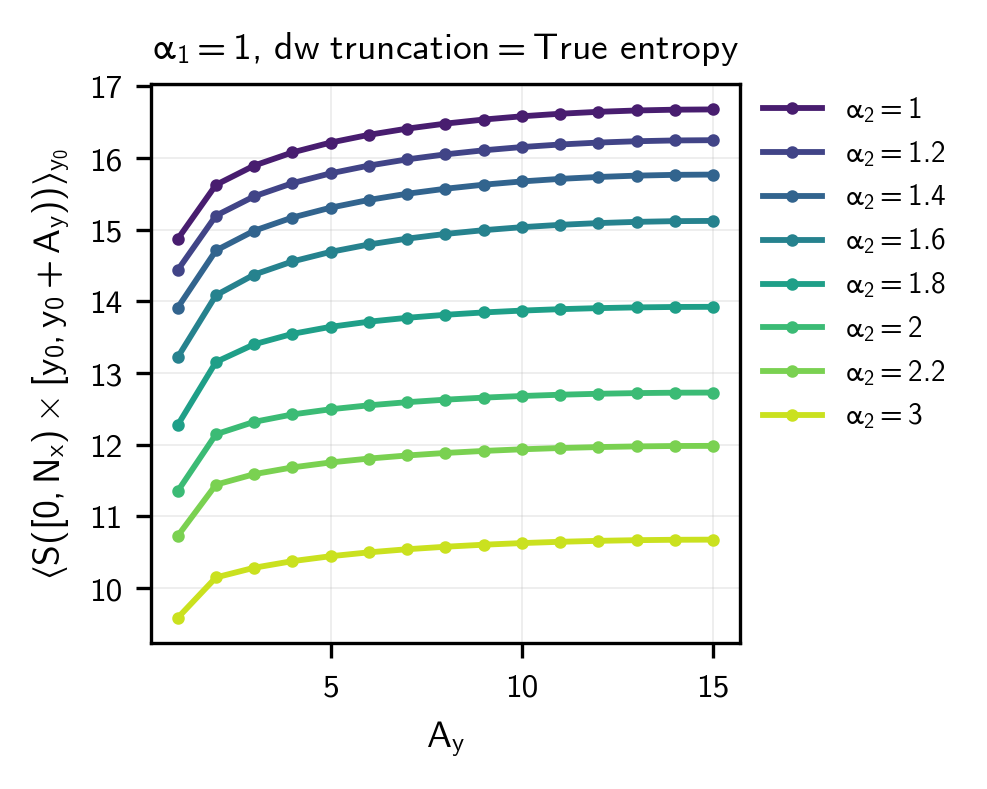

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.7))

fixed_alpha1_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(FIXED_ALPHA1_ALPHA2_VALUES)))
for color, alpha_2 in zip(fixed_alpha1_colors, FIXED_ALPHA1_ALPHA2_VALUES):
    entropy_data = results[True][alpha_2]["entropy_data"]
    ax.plot(
        entropy_data["Ay_values"],
        entropy_data["avg_entropy"],
        marker="o",
        markersize=2.0,
        color=color,
        label=rf"$\alpha_2={alpha_2}$",
    )
ax.set_title(r"$\alpha_1=1$, $dw\ truncation=True$ entropy")
ax.set_xlabel(r"$A_y$")
ax.set_ylabel(r"$\langle S([0,N_x) \times [y_0, y_0 + A_y)) \rangle_{y_0}$")
ax.grid(alpha=0.25, linewidth=0.4)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, ncol=1, borderaxespad=0)
fig.tight_layout()
plt.show()


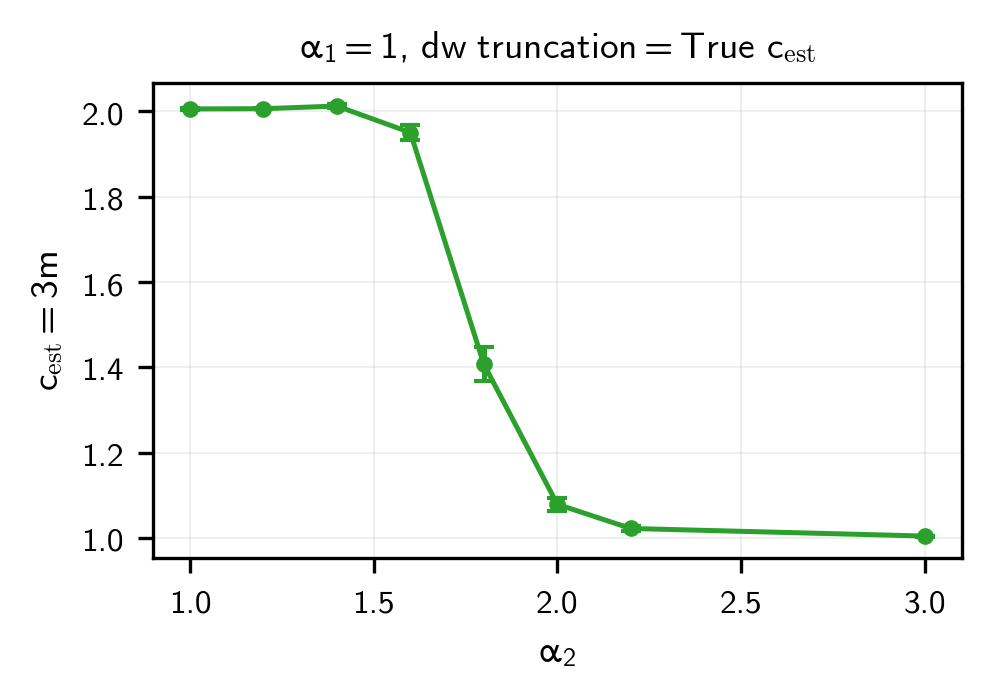

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.4))
ax.errorbar(
    fixed_alpha1_dwtrunc_df["alpha_2"],
    fixed_alpha1_dwtrunc_df["c_est"],
    yerr=fixed_alpha1_dwtrunc_df["c_est_err"],
    marker="o",
    markersize=3.0,
    color="tab:green",
    linewidth=1.2,
    capsize=2.5,
)
ax.set_title(r"$\alpha_1=1$, $dw\ truncation=True$ $c_{\mathrm{est}}$")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$c_{\mathrm{est}} = 3m$")
ax.grid(alpha=0.25, linewidth=0.4)
fig.tight_layout()
plt.show()


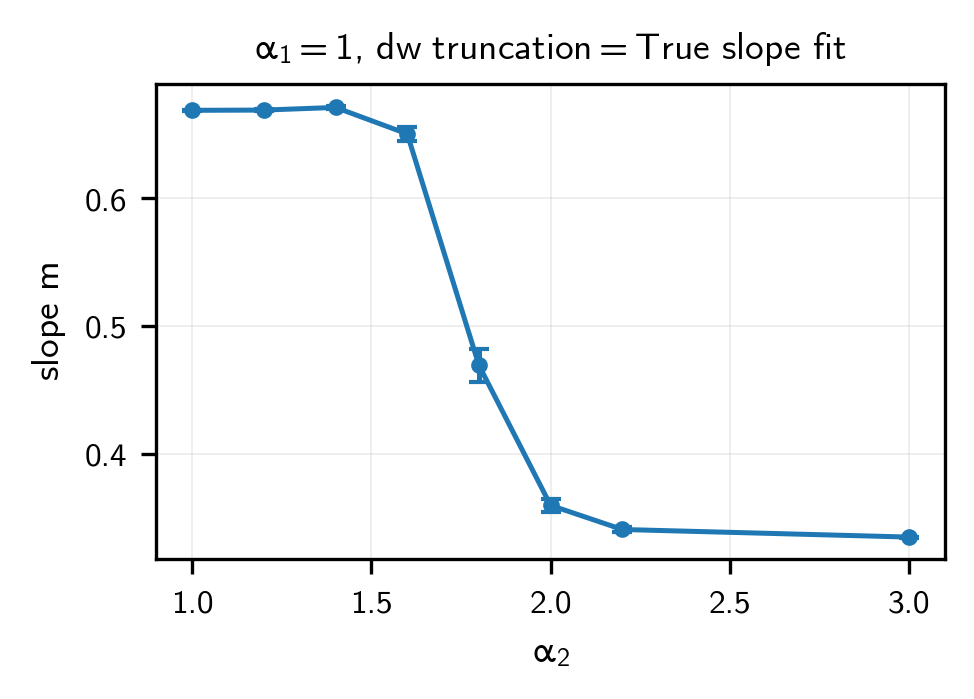

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.4))
ax.errorbar(
    fixed_alpha1_dwtrunc_df["alpha_2"],
    fixed_alpha1_dwtrunc_df["slope"],
    yerr=fixed_alpha1_dwtrunc_df["slope_err"],
    marker="o",
    markersize=3.0,
    color="tab:blue",
    linewidth=1.2,
    capsize=2.5,
)
ax.set_title(r"$\alpha_1=1$, $dw\ truncation=True$ slope fit")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"slope $m$")
ax.grid(alpha=0.25, linewidth=0.4)
fig.tight_layout()
plt.show()


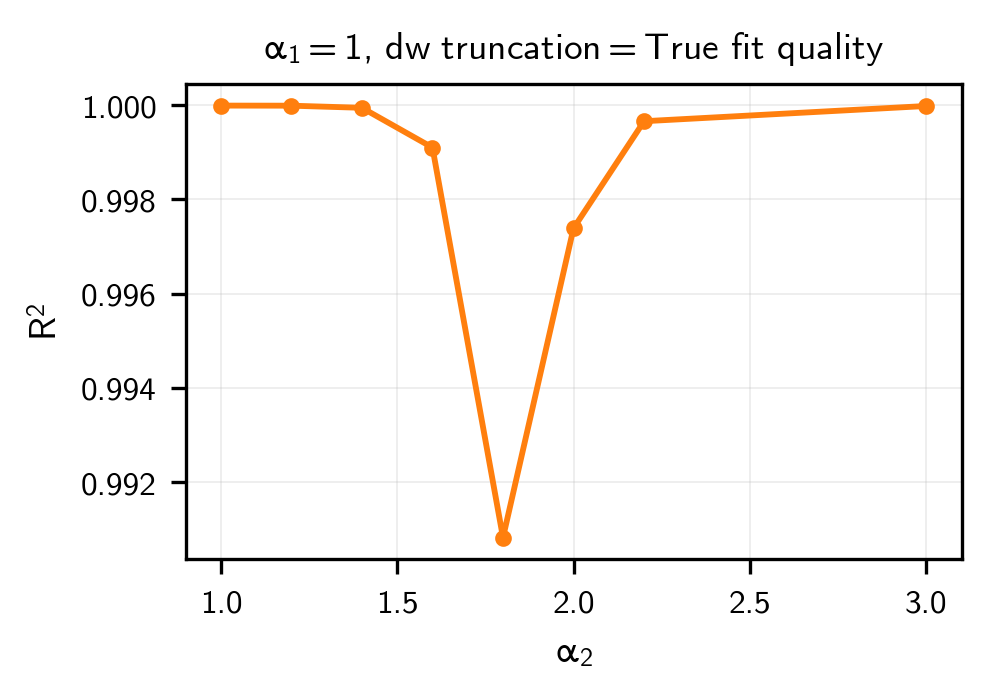

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(3.375, 2.4))
ax.plot(
    fixed_alpha1_dwtrunc_df["alpha_2"],
    fixed_alpha1_dwtrunc_df["r2"],
    marker="o",
    markersize=3.0,
    color="tab:orange",
)
ax.set_title(r"$\alpha_1=1$, $dw\ truncation=True$ fit quality")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$R^2$")
ax.grid(alpha=0.25, linewidth=0.4)
fig.tight_layout()
plt.show()


In [25]:
fixed_alpha1_dwtrunc_df[[
    "alpha_1",
    "alpha_2",
    "c_est",
    "c_est_err",
    "slope",
    "slope_err",
    "r2",
    "spectral_gap",
    "occ_count",
    "neg_count",
    "fallback_used",
]]


,alpha_1,alpha_2,c_est,c_est_err,slope,slope_err,r2,spectral_gap,occ_count,neg_count,fallback_used
0,1.0,1.0,2.005874,0.001626,0.668625,0.000542,0.999992,7.511085e-10,600,600,False
1,1.0,1.2,2.006412,0.001801,0.668804,0.000600,0.999990,7.511071e-10,600,600,False
2,1.0,1.4,2.012633,0.004298,0.670878,0.001433,0.999945,7.511083e-10,600,600,False
3,1.0,1.6,1.950542,0.016885,0.650181,0.005628,0.999102,7.511082e-10,600,600,False
4,1.0,1.8,1.407365,0.039097,0.469122,0.013032,0.990824,7.511077e-10,600,600,False
5,1.0,2.0,1.078684,0.015931,0.359561,0.005310,0.997389,7.511079e-10,600,600,False
6,1.0,2.2,1.022036,0.005436,0.340679,0.001812,0.999661,7.511078e-10,600,600,False
7,1.0,3.0,1.004256,0.001168,0.334752,0.000389,0.999984,7.511082e-10,600,600,False


## Post-Selected Markov Circuit Run (DW=True, fixed alpha_1=1, alpha_2 sweep)

Runs `run_markov_circuit` with post-selection =True for 10 cycles on a 16×32 system with `nshell=1`, `DW=True`, `dw_truncation=True`, fixed `alpha_1=1`, sweeping `alpha_2` over `[1, 1.5, 2, 3]`. Extracts final-state entropy, fits the log-chord form, and reports `c_est` and `R²` vs `alpha_2`.


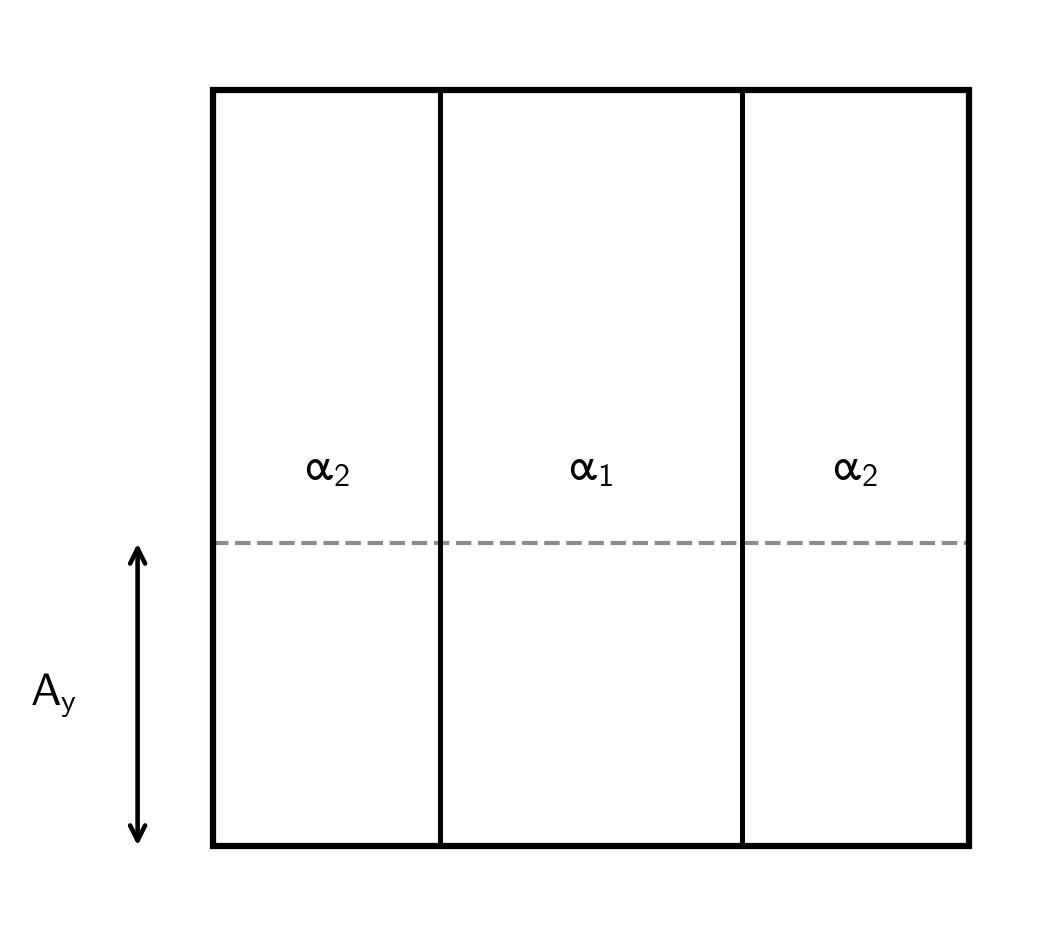

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "CMU Sans Serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
})

# -----------------------------
# Geometry
# -----------------------------
Lx = 2.0          # horizontal length
Ly = 2.0        # vertical length
x0 = 0.0          # left wall position
y0 = 0.0          # bottom line position

xc = x0 + Lx / 2
yc = y0 + Ly / 2

x_left_cut = xc - 0.2 * Lx
x_right_cut = xc + 0.2 * Lx

y_hline = y0 + 0.4 * Ly

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(3.375, 3.375), dpi=300)

# Outer rectangle
rect = patches.Rectangle(
    (x0, y0),
    Lx,
    Ly,
    fill=False,
    linewidth=1.5,
    edgecolor="black",
)
ax.add_patch(rect)

# Vertical internal lines
ax.plot([x_left_cut, x_left_cut], [y0, y0 + Ly], color="black", linewidth=1.2)
ax.plot([x_right_cut, x_right_cut], [y0, y0 + Ly], color="black", linewidth=1.2)

# Dashed horizontal line
ax.plot(
    [x0, x0 + Lx],
    [y_hline, y_hline],
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.45,
)

# Region labels
ax.text(
    xc,
    yc,
    r"$\alpha_1$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x0 + x_left_cut) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x_right_cut + x0 + Lx) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

# Double-headed arrow outside the rectangle, adjacent to left wall
arrow_x = x0 - 0.10 * Lx
ax.annotate(
    "",
    xy=(arrow_x, y_hline),
    xytext=(arrow_x, y0),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=1.1,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
)

# Ay label to the left of the double-headed arrow
ax.text(
    arrow_x - 0.08 * Lx,
    0.5 * (y0 + y_hline),
    r"$A_y$",
    ha="right",
    va="center",
    fontsize=11,
)

# -----------------------------
# Formatting
# -----------------------------
pad = 0.22 * Lx
ax.set_xlim(x0 - pad, x0 + Lx + 0.08 * Lx)
ax.set_ylim(y0 - 0.08 * Ly, y0 + Ly + 0.08 * Ly)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()

In [27]:
MC_NX, MC_NY = 16, 20
MC_NSHELL = 1
MC_ALPHA_1 = 1
MC_ALPHA_2_VALUES = [1, 1.5, 2, 3]
MC_CYCLES = 20
MC_DW = True
MC_DW_TRUNCATION = True
MC_AY_VALUES = list(range(1, MC_NY // 2 + 1))

MC_N_LAYER = 2 * MC_NX * MC_NY
print(f"MC system: {MC_NX}x{MC_NY}, nshell={MC_NSHELL}, DW={MC_DW}, dw_truncation={MC_DW_TRUNCATION}, cycles={MC_CYCLES}")
print(f"MC_N_LAYER={MC_N_LAYER}, alpha_1={MC_ALPHA_1}, alpha_2 sweep={MC_ALPHA_2_VALUES}")


MC system: 16x20, nshell=1, DW=True, dw_truncation=True, cycles=20
MC_N_LAYER=640, alpha_1=1, alpha_2 sweep=[1, 1.5, 2, 3]


In [28]:
import warnings
from scipy.linalg import eigvalsh as sp_eigvalsh

def mc_avg_entropy_vs_ay(G, nx, ny, ay_values, clip_eps=1e-12):
    if not np.all(np.isfinite(G)):
        raise ValueError(
            f"G_final contains non-finite values: "
            f"{np.sum(~np.isfinite(G))} NaN/Inf entries out of {G.size}"
        )
    avg_ents = []
    for Ay in ay_values:
        ents = []
        for y0 in range(ny):
            idx = []
            for y in ((np.arange(Ay, dtype=int) + y0) % ny):
                base_y = 2 * nx * int(y)
                for x in range(nx):
                    idx.append(base_y + 2 * x)
                    idx.append(base_y + 2 * x + 1)
            idx = np.asarray(idx, dtype=int)
            G_sub = G[np.ix_(idx, idx)]
            rho_sub = 0.5 * (np.eye(G_sub.shape[0], dtype=np.complex128) + G_sub)
            rho_sub = 0.5 * (rho_sub + rho_sub.conj().T)
            try:
                lambdas = np.real(np.linalg.eigvalsh(rho_sub))
            except np.linalg.LinAlgError:
                # numpy LAPACK driver failed; try scipy divide-and-conquer driver
                lambdas = np.real(sp_eigvalsh(rho_sub, driver='evd', check_finite=False))
            lambdas = np.clip(lambdas, clip_eps, 1.0 - clip_eps)
            ents.append(float(-np.sum(lambdas * np.log(lambdas) + (1.0 - lambdas) * np.log(1.0 - lambdas))))
        avg_ents.append(float(np.mean(ents)))
    return np.asarray(avg_ents, dtype=float)

mc_results = {}
mc_summary_rows = []

for alpha_2 in MC_ALPHA_2_VALUES:
    print(f"  alpha_1={MC_ALPHA_1}, alpha_2={alpha_2}")
    model = classA_U1FGTN(
        MC_NX, MC_NY, DW=MC_DW, nshell=MC_NSHELL,
        alpha_1=MC_ALPHA_1, alpha_2=alpha_2,
        dw_truncation=MC_DW_TRUNCATION,
    )
    with warnings.catch_warnings(record=True):
        warnings.simplefilter("always")
        result = model.run_markov_circuit(cycles=MC_CYCLES, G_history=False, save=False, postselect=True)
    G_final = result["G_final"][-1]
    avg_entropy = mc_avg_entropy_vs_ay(G_final, MC_NX, MC_NY, MC_AY_VALUES)
    fit = fit_entropy_logchord(np.asarray(MC_AY_VALUES, dtype=int), avg_entropy, ny=MC_NY, fit_ay_min=ENTROPY_FIT_AY_MIN)
    mc_results[alpha_2] = {
        "G_final": G_final,
        "avg_entropy": avg_entropy,
        "fit": fit,
    }
    mc_summary_rows.append({
        "alpha_2": float(alpha_2),
        "slope": float(fit["slope"]),
        "slope_err": float(fit["slope_err"]),
        "c_est": float(fit["c_est"]),
        "c_est_err": float(fit["c_est_err"]),
        "r2": float(fit["r2"]),
    })
    print(f"    \u2192 c_est={fit['c_est']:.4f} \u00b1 {fit['c_est_err']:.4f}, R\u00b2={fit['r2']:.4f}")

mc_summary_df = pd.DataFrame(mc_summary_rows)
mc_summary_df


  alpha_1=1, alpha_2=1
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (sites):   0%|          | 0/6400 [00:00<?, ?site/s]

    → c_est=2.0722 ± 0.0060, R²=0.9999
  alpha_1=1, alpha_2=1.5
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (sites):   0%|          | 0/6400 [00:00<?, ?site/s]

    → c_est=2.0150 ± 0.0153, R²=0.9996
  alpha_1=1, alpha_2=2
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (sites):   0%|          | 0/6400 [00:00<?, ?site/s]

    → c_est=1.1039 ± 0.0199, R²=0.9977
  alpha_1=1, alpha_2=3
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (sites):   0%|          | 0/6400 [00:00<?, ?site/s]

    → c_est=1.0336 ± 0.0059, R²=0.9998


,alpha_2,slope,slope_err,c_est,c_est_err,r2
0,1.0,0.690741,0.002013,2.072223,0.006039,0.999941
1,1.5,0.671669,0.005099,2.015006,0.015297,0.999597
2,2.0,0.367957,0.006650,1.103870,0.019949,0.997719
3,3.0,0.344537,0.001971,1.033612,0.005914,0.999771


In [29]:
print(result.keys())

dict_keys(['G_final', 'G_final_avg', 'samples', 'T', 'save_path', 'postselect_probability'])


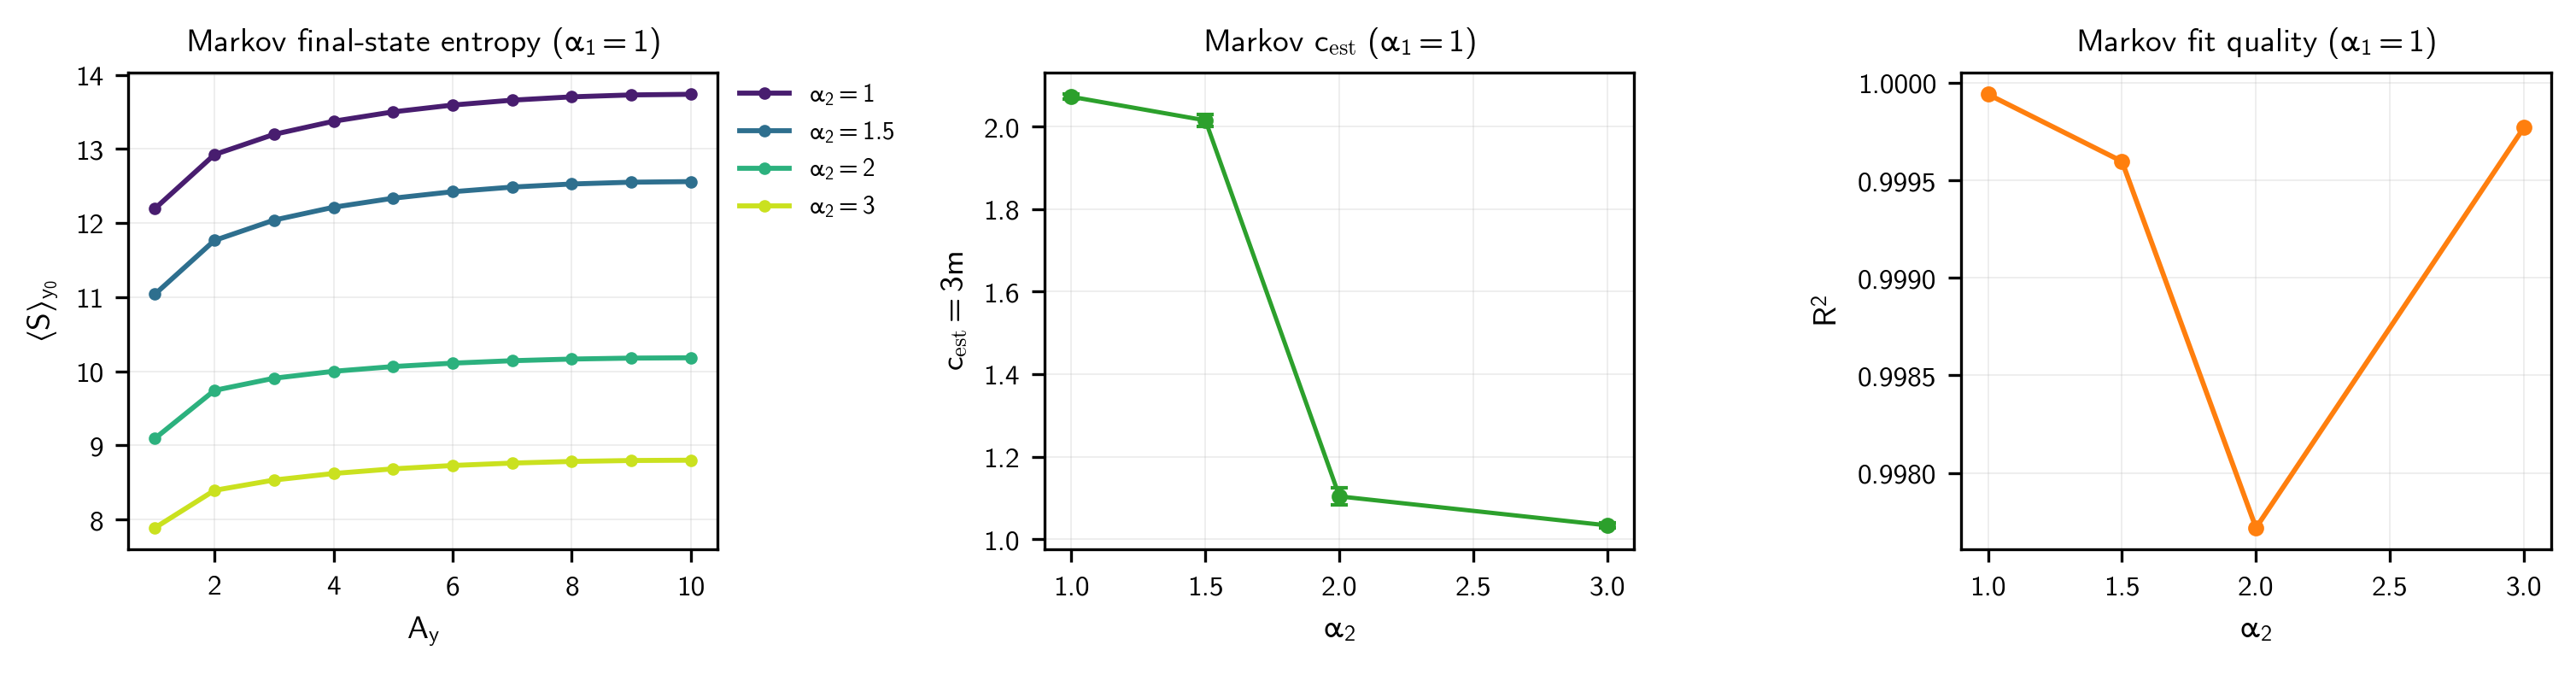

In [30]:
mc_alpha2_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(MC_ALPHA_2_VALUES)))
mc_ay_arr = np.asarray(MC_AY_VALUES, dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(3 * 3.375, 2.7))

# --- entropy vs Ay (final state) ---
ax = axes[0]
for color, alpha_2 in zip(mc_alpha2_colors, MC_ALPHA_2_VALUES):
    ax.plot(mc_ay_arr, mc_results[alpha_2]["avg_entropy"], marker="o", markersize=2.5, color=color, label=rf"$\alpha_2={alpha_2}$")
ax.set_title(rf"Markov final-state entropy ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$A_y$")
ax.set_ylabel(r"$\langle S \rangle_{y_0}$")
ax.grid(alpha=0.25, linewidth=0.4)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, ncol=1, borderaxespad=0, fontsize=7)

# --- c_est vs alpha_2 ---
ax = axes[1]
ax.errorbar(mc_summary_df["alpha_2"], mc_summary_df["c_est"], yerr=mc_summary_df["c_est_err"],
    marker="o", markersize=3.5, color="tab:green", linewidth=1.2, capsize=2.5)
ax.set_title(rf"Markov $c_{{\mathrm{{est}}}}$ ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$c_{\mathrm{est}} = 3m$")
ax.grid(alpha=0.25, linewidth=0.4)

# --- R² vs alpha_2 ---
ax = axes[2]
ax.plot(mc_summary_df["alpha_2"], mc_summary_df["r2"], marker="o", markersize=3.5, color="tab:orange")
ax.set_title(rf"Markov fit quality ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$R^2$")
ax.grid(alpha=0.25, linewidth=0.4)

fig.tight_layout()
plt.show()


## Perfect-Correction Markov Circuit Run (DW=True, fixed alpha_1=1, alpha_2 sweep)

Runs `run_markov_circuit` with perfect-correction =True for 10 cycles on a 16×32 system with `nshell=1`, `DW=True`, `dw_truncation=True`, fixed `alpha_1=1`, sweeping `alpha_2` over `[1, 1.5, 2, 3]`. Extracts final-state entropy, fits the log-chord form, and reports `c_est` and `R²` vs `alpha_2`.


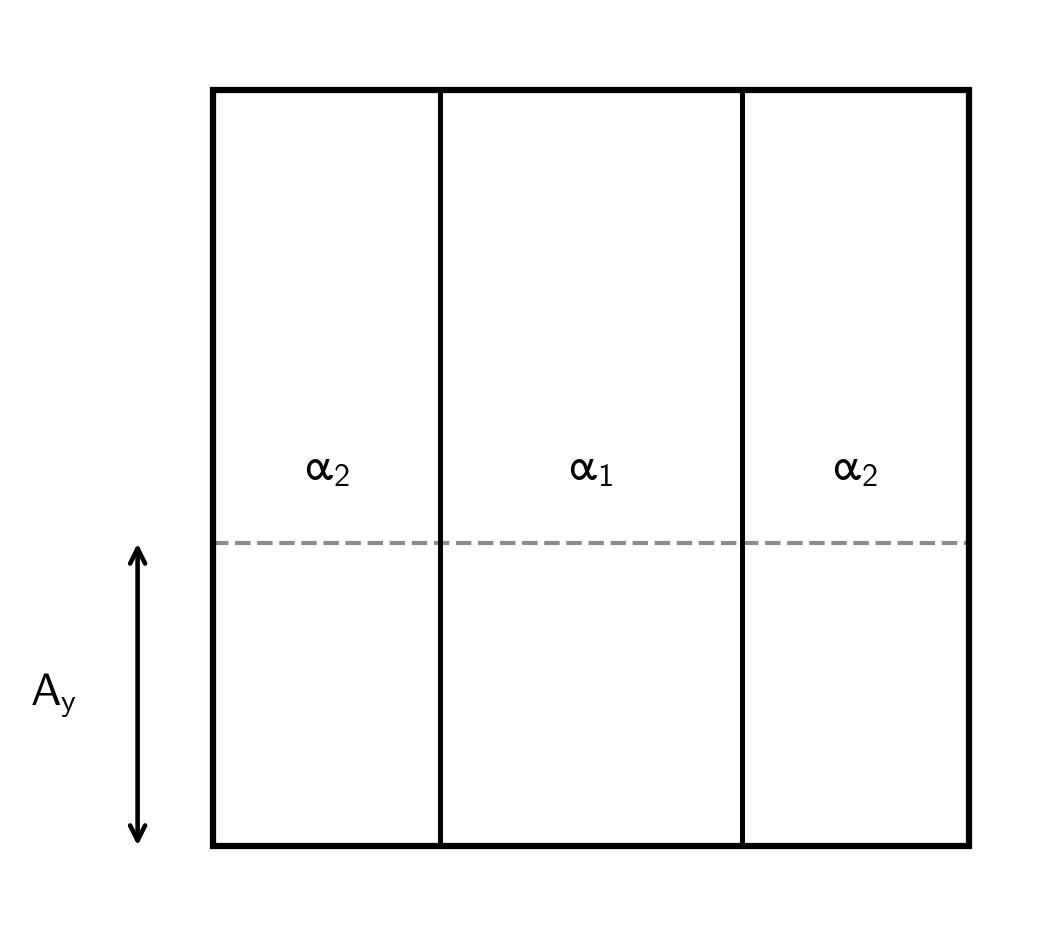

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "CMU Sans Serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
})

# -----------------------------
# Geometry
# -----------------------------
Lx = 2.0          # horizontal length
Ly = 2.0        # vertical length
x0 = 0.0          # left wall position
y0 = 0.0          # bottom line position

xc = x0 + Lx / 2
yc = y0 + Ly / 2

x_left_cut = xc - 0.2 * Lx
x_right_cut = xc + 0.2 * Lx

y_hline = y0 + 0.4 * Ly

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(3.375, 3.375), dpi=300)

# Outer rectangle
rect = patches.Rectangle(
    (x0, y0),
    Lx,
    Ly,
    fill=False,
    linewidth=1.5,
    edgecolor="black",
)
ax.add_patch(rect)

# Vertical internal lines
ax.plot([x_left_cut, x_left_cut], [y0, y0 + Ly], color="black", linewidth=1.2)
ax.plot([x_right_cut, x_right_cut], [y0, y0 + Ly], color="black", linewidth=1.2)

# Dashed horizontal line
ax.plot(
    [x0, x0 + Lx],
    [y_hline, y_hline],
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.45,
)

# Region labels
ax.text(
    xc,
    yc,
    r"$\alpha_1$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x0 + x_left_cut) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    (x_right_cut + x0 + Lx) / 2,
    yc,
    r"$\alpha_2$",
    ha="center",
    va="center",
    fontsize=11,
)

# Double-headed arrow outside the rectangle, adjacent to left wall
arrow_x = x0 - 0.10 * Lx
ax.annotate(
    "",
    xy=(arrow_x, y_hline),
    xytext=(arrow_x, y0),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=1.1,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
)

# Ay label to the left of the double-headed arrow
ax.text(
    arrow_x - 0.08 * Lx,
    0.5 * (y0 + y_hline),
    r"$A_y$",
    ha="right",
    va="center",
    fontsize=11,
)

# -----------------------------
# Formatting
# -----------------------------
pad = 0.22 * Lx
ax.set_xlim(x0 - pad, x0 + Lx + 0.08 * Lx)
ax.set_ylim(y0 - 0.08 * Ly, y0 + Ly + 0.08 * Ly)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()

In [32]:
MC_NX, MC_NY = 16, 20
MC_NSHELL = 1
MC_ALPHA_1 = 1
MC_ALPHA_2_VALUES = [1, 1.5, 2, 3]
MC_CYCLES = 20
MC_DW = True
MC_DW_TRUNCATION = True
MC_AY_VALUES = list(range(1, MC_NY // 2 + 1))

MC_N_LAYER = 2 * MC_NX * MC_NY
print(f"MC system: {MC_NX}x{MC_NY}, nshell={MC_NSHELL}, DW={MC_DW}, dw_truncation={MC_DW_TRUNCATION}, cycles={MC_CYCLES}")
print(f"MC_N_LAYER={MC_N_LAYER}, alpha_1={MC_ALPHA_1}, alpha_2 sweep={MC_ALPHA_2_VALUES}")


MC system: 16x20, nshell=1, DW=True, dw_truncation=True, cycles=20
MC_N_LAYER=640, alpha_1=1, alpha_2 sweep=[1, 1.5, 2, 3]


In [33]:
import warnings

def mc_avg_entropy_vs_ay(G, nx, ny, ay_values, clip_eps=1e-12):
    avg_ents = []
    for Ay in ay_values:
        ents = []
        for y0 in range(ny):
            idx = []
            for y in ((np.arange(Ay, dtype=int) + y0) % ny):
                base_y = 2 * nx * int(y)
                for x in range(nx):
                    idx.append(base_y + 2 * x)
                    idx.append(base_y + 2 * x + 1)
            idx = np.asarray(idx, dtype=int)
            G_sub = G[np.ix_(idx, idx)]
            rho_sub = 0.5 * (np.eye(G_sub.shape[0], dtype=np.complex128) + G_sub)
            rho_sub = 0.5 * (rho_sub + rho_sub.conj().T)
            lambdas = np.clip(np.real(np.linalg.eigvalsh(rho_sub)), clip_eps, 1.0 - clip_eps)
            ents.append(float(-np.sum(lambdas * np.log(lambdas) + (1.0 - lambdas) * np.log(1.0 - lambdas))))
        avg_ents.append(float(np.mean(ents)))
    return np.asarray(avg_ents, dtype=float)

mc_results = {}
mc_summary_rows = []

for alpha_2 in MC_ALPHA_2_VALUES:
    print(f"  alpha_1={MC_ALPHA_1}, alpha_2={alpha_2}")
    model = classA_U1FGTN(
        MC_NX, MC_NY, DW=MC_DW, nshell=MC_NSHELL,
        alpha_1=MC_ALPHA_1, alpha_2=alpha_2,
        dw_truncation=MC_DW_TRUNCATION,
    )
    with warnings.catch_warnings(record=True):
        warnings.simplefilter("always")
        result = model.run_markov_circuit(cycles=MC_CYCLES, G_history=False, save=False, perfect_correction=True, samples=1, parallelize_samples=False)
    G_final = result["G_final"][-1]
    avg_entropy = mc_avg_entropy_vs_ay(G_final, MC_NX, MC_NY, MC_AY_VALUES)
    fit = fit_entropy_logchord(np.asarray(MC_AY_VALUES, dtype=int), avg_entropy, ny=MC_NY, fit_ay_min=ENTROPY_FIT_AY_MIN)
    mc_results[alpha_2] = {
        "G_final": G_final,
        "avg_entropy": avg_entropy,
        "fit": fit,
    }
    mc_summary_rows.append({
        "alpha_2": float(alpha_2),
        "slope": float(fit["slope"]),
        "slope_err": float(fit["slope_err"]),
        "c_est": float(fit["c_est"]),
        "c_est_err": float(fit["c_est_err"]),
        "r2": float(fit["r2"]),
    })
    print(f"    → c_est={fit['c_est']:.4f} ± {fit['c_est_err']:.4f}, R²={fit['r2']:.4f}")

mc_summary_df = pd.DataFrame(mc_summary_rows)
mc_summary_df


  alpha_1=1, alpha_2=1
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (sites):   0%|          | 0/6400 [00:00<?, ?site/s]

LinAlgError: Eigenvalues did not converge

In [ ]:
mc_alpha2_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(MC_ALPHA_2_VALUES)))
mc_ay_arr = np.asarray(MC_AY_VALUES, dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(3 * 3.375, 2.7))

# --- entropy vs Ay (final state) ---
ax = axes[0]
for color, alpha_2 in zip(mc_alpha2_colors, MC_ALPHA_2_VALUES):
    ax.plot(mc_ay_arr, mc_results[alpha_2]["avg_entropy"], marker="o", markersize=2.5, color=color, label=rf"$\alpha_2={alpha_2}$")
ax.set_title(rf"Markov final-state entropy ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$A_y$")
ax.set_ylabel(r"$\langle S \rangle_{y_0}$")
ax.grid(alpha=0.25, linewidth=0.4)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, ncol=1, borderaxespad=0, fontsize=7)

# --- c_est vs alpha_2 ---
ax = axes[1]
ax.errorbar(mc_summary_df["alpha_2"], mc_summary_df["c_est"], yerr=mc_summary_df["c_est_err"],
    marker="o", markersize=3.5, color="tab:green", linewidth=1.2, capsize=2.5)
ax.set_title(rf"Markov $c_{{\mathrm{{est}}}}$ ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$c_{\mathrm{est}} = 3m$")
ax.grid(alpha=0.25, linewidth=0.4)

# --- R² vs alpha_2 ---
ax = axes[2]
ax.plot(mc_summary_df["alpha_2"], mc_summary_df["r2"], marker="o", markersize=3.5, color="tab:orange")
ax.set_title(rf"Markov fit quality ($\alpha_1={MC_ALPHA_1}$)")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel(r"$R^2$")
ax.grid(alpha=0.25, linewidth=0.4)

fig.tight_layout()
plt.show()
